# Jaccard Similarity Analysis: Llama vs Mistral

For each statement and conformal method (LAC, APS, OrdinalAPS), this notebook
compares the prediction sets produced by Llama-3.1-8B and Mistral-7B using:

- **Jaccard similarity** of their modal prediction sets (most-frequent set across trials)
- **Set size correlation** (Spearman ρ per statement, averaged over trials)
- **Coverage rate correlation**
- **Per-category breakdown** via heatmaps
- **Summary statistics** table

The *modal set* is the prediction set that appeared most often across all 100 trials
for a given statement.  Because calibration/test splits are random, Llama trial *i*
and Mistral trial *i* are independent — so Jaccard is computed on the modal sets
rather than trial-aligned pairs.


In [6]:
import ast
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from collections import Counter

os.makedirs("visualisations_Jaccard", exist_ok=True)

CATEGORIES = ['crime', 'economy', 'education', 'elections',
              'health-care', 'immigration', 'jobs', 'taxes']
VERDICTS   = ['true', 'mostly-true', 'half-true', 'mostly-false', 'false', 'pants-fire']

CATEGORY_COLORS = {
    'crime':       '#E74C3C',
    'economy':     '#3498DB',
    'education':   '#2ECC71',
    'elections':   '#9B59B6',
    'health-care': '#F39C12',
    'immigration': '#1ABC9C',
    'jobs':        '#E67E22',
    'taxes':       '#95A5A6',
}

BASE = r'C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results'

# ── LAC ──────────────────────────────────────────────────────────────────
no_evidence_lac_llama_csv = {
    'crime':       f'{BASE}/llama/zero-shot-lac/crime/conformal_results_all_trials_100trials_20260327_141313.csv',
    'economy':     f'{BASE}/llama/zero-shot-lac/economy/conformal_results_all_trials_100trials_20260327_153533.csv',
    'education':   f'{BASE}/llama/zero-shot-lac/education/conformal_results_all_trials_100trials_20260327_143823.csv',
    'elections':   f'{BASE}/llama/zero-shot-lac/elections/conformal_results_all_trials_100trials_20260327_153731.csv',
    'health-care': f'{BASE}/llama/zero-shot-lac/health-care/conformal_results_all_trials_100trials_20260327_155654.csv',
    'immigration': f'{BASE}/llama/zero-shot-lac/immigration/conformal_results_all_trials_100trials_20260327_144131.csv',
    'jobs':        f'{BASE}/llama/zero-shot-lac/jobs/conformal_results_all_trials_100trials_20260327_142840.csv',
    'taxes':       f'{BASE}/llama/zero-shot-lac/taxes/conformal_results_all_trials_100trials_20260327_151637.csv',
}
with_evidence_lac_llama_csv = {
    'crime':       f'{BASE}/llama/zero-shot-lac-evidence/crime/conformal_results_all_trials_100trials_20260407_071658.csv',
    'economy':     f'{BASE}/llama/zero-shot-lac-evidence/economy/conformal_results_all_trials_100trials_20260407_140549.csv',
    'education':   f'{BASE}/llama/zero-shot-lac-evidence/education/conformal_results_all_trials_100trials_20260407_102821.csv',
    'elections':   f'{BASE}/llama/zero-shot-lac-evidence/elections/conformal_results_all_trials_100trials_20260407_134947.csv',
    'health-care': f'{BASE}/llama/zero-shot-lac-evidence/health-care/conformal_results_all_trials_100trials_20260407_163030.csv',
    'immigration': f'{BASE}/llama/zero-shot-lac-evidence/immigration/conformal_results_all_trials_100trials_20260407_102713.csv',
    'jobs':        f'{BASE}/llama/zero-shot-lac-evidence/jobs/conformal_results_all_trials_100trials_20260407_084803.csv',
    'taxes':       f'{BASE}/llama/zero-shot-lac-evidence/taxes/conformal_results_all_trials_100trials_20260407_122809.csv',
}
no_evidence_lac_mistral_csv = {
    'crime':       f'{BASE}/mistral/zero-shot-lac/crime/conformal_results_all_trials_100trials_20260412_170140.csv',
    'economy':     f'{BASE}/mistral/zero-shot-lac/economy/conformal_results_all_trials_100trials_20260412_235417.csv',
    'education':   f'{BASE}/mistral/zero-shot-lac/education/conformal_results_all_trials_100trials_20260412_172745.csv',
    'elections':   f'{BASE}/mistral/zero-shot-lac/elections/conformal_results_all_trials_100trials_20260412_234002.csv',
    'health-care': f'{BASE}/mistral/zero-shot-lac/health-care/conformal_results_all_trials_100trials_20260413_030310.csv',
    'immigration': f'{BASE}/mistral/zero-shot-lac/immigration/conformal_results_all_trials_100trials_20260413_020109.csv',
    'jobs':        f'{BASE}/mistral/zero-shot-lac/jobs/conformal_results_all_trials_100trials_20260413_020352.csv',
    'taxes':       f'{BASE}/mistral/zero-shot-lac/taxes/conformal_results_all_trials_100trials_20260413_030120.csv',
}
with_evidence_lac_mistral_csv = {
    'crime':       f'{BASE}/mistral/zero-shot-lac-evidence/crime/conformal_results_all_trials_100trials_20260414_154947.csv',
    'economy':     f'{BASE}/mistral/zero-shot-lac-evidence/economy/conformal_results_all_trials_100trials_20260426_003936.csv',
    'education':   f'{BASE}/mistral/zero-shot-lac-evidence/education/conformal_results_all_trials_100trials_20260414_173101.csv',
    'elections':   f'{BASE}/mistral/zero-shot-lac-evidence/elections/conformal_results_all_trials_100trials_20260415_041233.csv',
    'health-care': f'{BASE}/mistral/zero-shot-lac-evidence/health-care/conformal_results_all_trials_100trials_20260503_192034.csv',
    'immigration': f'{BASE}/mistral/zero-shot-lac-evidence/immigration/conformal_results_all_trials_100trials_20260427_085329.csv',
    'jobs':        f'{BASE}/mistral/zero-shot-lac-evidence/jobs/conformal_results_all_trials_100trials_20260427_070511.csv',
    'taxes':       f'{BASE}/mistral/zero-shot-lac-evidence/taxes/conformal_results_all_trials_100trials_20260427_105625.csv',
}

# ── APS ──────────────────────────────────────────────────────────────────
no_evidence_aps_llama_csv = {
    'crime':       f'{BASE}/llama/zero-shot-aps/crime/conformal_results_aps_all_trials_100trials_20260501_010529.csv',
    'economy':     f'{BASE}/llama/zero-shot-aps/economy/conformal_results_aps_all_trials_100trials_20260501_030659.csv',
    'education':   f'{BASE}/llama/zero-shot-aps/education/conformal_results_aps_all_trials_100trials_20260501_022015.csv',
    'elections':   f'{BASE}/llama/zero-shot-aps/elections/conformal_results_aps_all_trials_100trials_20260501_032421.csv',
    'health-care': f'{BASE}/llama/zero-shot-aps/health-care/conformal_results_aps_all_trials_100trials_20260501_042748.csv',
    'immigration': f'{BASE}/llama/zero-shot-aps/immigration/conformal_results_aps_all_trials_100trials_20260501_034726.csv',
    'jobs':        f'{BASE}/llama/zero-shot-aps/jobs/conformal_results_aps_all_trials_100trials_20260501_033545.csv',
    'taxes':       f'{BASE}/llama/zero-shot-aps/taxes/conformal_results_aps_all_trials_100trials_20260501_043609.csv',
}
with_evidence_aps_llama_csv = {
    'crime':       f'{BASE}/llama/zero-shot-aps-evidence/crime/conformal_results_aps_all_trials_100trials_20260503_174721.csv',
    'economy':     f'{BASE}/llama/zero-shot-aps-evidence/economy/conformal_results_aps_all_trials_100trials_20260503_233854.csv',
    'education':   f'{BASE}/llama/zero-shot-aps-evidence/education/conformal_results_aps_all_trials_100trials_20260503_221646.csv',
    'elections':   f'{BASE}/llama/zero-shot-aps-evidence/elections/conformal_results_aps_all_trials_100trials_20260504_011728.csv',
    'health-care': f'{BASE}/llama/zero-shot-aps-evidence/health-care/conformal_results_aps_all_trials_100trials_20260504_034503.csv',
    'immigration': f'{BASE}/llama/zero-shot-aps-evidence/immigration/conformal_results_aps_all_trials_100trials_20260505_175416.csv',
    'jobs':        f'{BASE}/llama/zero-shot-aps-evidence/jobs/conformal_results_aps_all_trials_100trials_20260503_233509.csv',
    'taxes':       f'{BASE}/llama/zero-shot-aps-evidence/taxes/conformal_results_aps_all_trials_100trials_20260504_044716.csv',
}
no_evidence_aps_mistral_csv = {
    'crime':       f'{BASE}/mistral/zero-shot-aps/crime/conformal_results_aps_all_trials_100trials_20260501_034109.csv',
    'economy':     f'{BASE}/mistral/zero-shot-aps/economy/conformal_results_aps_all_trials_100trials_20260501_062603.csv',
    'education':   f'{BASE}/mistral/zero-shot-aps/education/conformal_results_aps_all_trials_100trials_20260501_042519.csv',
    'elections':   f'{BASE}/mistral/zero-shot-aps/elections/conformal_results_aps_all_trials_100trials_20260501_063924.csv',
    'health-care': f'{BASE}/mistral/zero-shot-aps/health-care/conformal_results_aps_all_trials_100trials_20260501_065153.csv',
    'immigration': f'{BASE}/mistral/zero-shot-aps/immigration/conformal_results_aps_all_trials_100trials_20260501_054829.csv',
    'jobs':        f'{BASE}/mistral/zero-shot-aps/jobs/conformal_results_aps_all_trials_100trials_20260501_053623.csv',
    'taxes':       f'{BASE}/mistral/zero-shot-aps/taxes/conformal_results_aps_all_trials_100trials_20260502_123934.csv',
}
with_evidence_aps_mistral_csv = {
    'crime':       f'{BASE}/mistral/zero-shot-aps-evidence/crime/conformal_results_aps_all_trials_100trials_20260504_171419.csv',
    'economy':     f'{BASE}/mistral/zero-shot-aps-evidence/economy/conformal_results_aps_all_trials_100trials_20260504_222630.csv',
    'education':   f'{BASE}/mistral/zero-shot-aps-evidence/education/conformal_results_aps_all_trials_100trials_20260504_185120.csv',
    'elections':   f'{BASE}/mistral/zero-shot-aps-evidence/elections/conformal_results_aps_all_trials_100trials_20260504_221230.csv',
    'health-care': f'{BASE}/mistral/zero-shot-aps-evidence/health-care/conformal_results_aps_all_trials_100trials_20260507_233606.csv',
    'immigration': f'{BASE}/mistral/zero-shot-aps-evidence/immigration/conformal_results_aps_all_trials_100trials_20260504_191242.csv',
    'jobs':        f'{BASE}/mistral/zero-shot-aps-evidence/jobs/conformal_results_aps_all_trials_100trials_20260504_172249.csv',
    'taxes':       f'{BASE}/mistral/zero-shot-aps-evidence/taxes/conformal_results_aps_all_trials_100trials_20260504_211810.csv',
}

# ── OrdinalAPS ───────────────────────────────────────────────────────────
no_evidence_ordinalaps_llama_csv = {
    'crime':       f'{BASE}/llama/zero-shot-ordinal-aps/crime/conformal_results_ordinal_aps_all_trials_100trials_20260424_064720.csv',
    'economy':     f'{BASE}/llama/zero-shot-ordinal-aps/economy/conformal_results_ordinal_aps_all_trials_100trials_20260424_083456.csv',
    'education':   f'{BASE}/llama/zero-shot-ordinal-aps/education/conformal_results_ordinal_aps_all_trials_100trials_20260424_073035.csv',
    'elections':   f'{BASE}/llama/zero-shot-ordinal-aps/elections/conformal_results_ordinal_aps_all_trials_100trials_20260424_083008.csv',
    'health-care': f'{BASE}/llama/zero-shot-ordinal-aps/health-care/conformal_results_ordinal_aps_all_trials_100trials_20260424_114328.csv',
    'immigration': f'{BASE}/llama/zero-shot-ordinal-aps/immigration/conformal_results_ordinal_aps_all_trials_100trials_20260424_104754.csv',
    'jobs':        f'{BASE}/llama/zero-shot-ordinal-aps/jobs/conformal_results_ordinal_aps_all_trials_100trials_20260424_105512.csv',
    'taxes':       f'{BASE}/llama/zero-shot-ordinal-aps/taxes/conformal_results_ordinal_aps_all_trials_100trials_20260424_113144.csv',
}
with_evidence_ordinalaps_llama_csv = {
    'crime':       f'{BASE}/llama/zero-shot-ordinal-aps-evidence/crime/conformal_results_ordinal_aps_all_trials_100trials_20260505_161238.csv',
    'economy':     f'{BASE}/llama/zero-shot-ordinal-aps-evidence/economy/conformal_results_ordinal_aps_all_trials_100trials_20260509_061650.csv',
    'education':   f'{BASE}/llama/zero-shot-ordinal-aps-evidence/education/conformal_results_ordinal_aps_all_trials_100trials_20260509_031418.csv',
    'elections':   f'{BASE}/llama/zero-shot-ordinal-aps-evidence/elections/conformal_results_ordinal_aps_all_trials_100trials_20260505_210920.csv',
    'health-care': f'{BASE}/llama/zero-shot-ordinal-aps-evidence/health-care/conformal_results_ordinal_aps_all_trials_100trials_20260505_230716.csv',
    'immigration': f'{BASE}/llama/zero-shot-ordinal-aps-evidence/immigration/conformal_results_ordinal_aps_all_trials_100trials_20260505_181447.csv',
    'jobs':        f'{BASE}/llama/zero-shot-ordinal-aps-evidence/jobs/conformal_results_ordinal_aps_all_trials_100trials_20260505_164257.csv',
    'taxes':       f'{BASE}/llama/zero-shot-ordinal-aps-evidence/taxes/conformal_results_ordinal_aps_all_trials_100trials_20260507_175239.csv',
}
no_evidence_ordinalaps_mistral_csv = {
    'crime':       f'{BASE}/mistral/zero-shot-ordinal-aps/crime/conformal_results_ordinal_aps_all_trials_100trials_20260424_070123.csv',
    'economy':     f'{BASE}/mistral/zero-shot-ordinal-aps/economy/conformal_results_ordinal_aps_all_trials_100trials_20260424_082637.csv',
    'education':   f'{BASE}/mistral/zero-shot-ordinal-aps/education/conformal_results_ordinal_aps_all_trials_100trials_20260424_073118.csv',
    'elections':   f'{BASE}/mistral/zero-shot-ordinal-aps/elections/conformal_results_ordinal_aps_all_trials_100trials_20260424_082351.csv',
    'health-care': f'{BASE}/mistral/zero-shot-ordinal-aps/health-care/conformal_results_ordinal_aps_all_trials_100trials_20260424_115129.csv',
    'immigration': f'{BASE}/mistral/zero-shot-ordinal-aps/immigration/conformal_results_ordinal_aps_all_trials_100trials_20260424_104349.csv',
    'jobs':        f'{BASE}/mistral/zero-shot-ordinal-aps/jobs/conformal_results_ordinal_aps_all_trials_100trials_20260424_123810.csv',
    'taxes':       f'{BASE}/mistral/zero-shot-ordinal-aps/taxes/conformal_results_ordinal_aps_all_trials_100trials_20260424_112451.csv',
}
with_evidence_ordinalaps_mistral_csv = {
    'crime':       f'{BASE}/mistral/zero-shot-ordinal-aps-evidence/crime/conformal_results_ordinal_aps_all_trials_100trials_20260507_143631.csv',
    'economy':     f'{BASE}/mistral/zero-shot-ordinal-aps-evidence/economy/conformal_results_ordinal_aps_all_trials_100trials_20260507_204034.csv',
    'education':   f'{BASE}/mistral/zero-shot-ordinal-aps-evidence/education/conformal_results_ordinal_aps_all_trials_100trials_20260507_170836.csv',
    'elections':   f'{BASE}/mistral/zero-shot-ordinal-aps-evidence/elections/conformal_results_ordinal_aps_all_trials_100trials_20260507_202047.csv',
    'health-care': f'{BASE}/mistral/zero-shot-ordinal-aps-evidence/health-care/conformal_results_ordinal_aps_all_trials_100trials_20260507_221705.csv',
    'immigration': f'{BASE}/mistral/zero-shot-ordinal-aps-evidence/immigration/conformal_results_ordinal_aps_all_trials_100trials_20260509_043122.csv',
    'jobs':        f'{BASE}/mistral/zero-shot-ordinal-aps-evidence/jobs/conformal_results_ordinal_aps_all_trials_100trials_20260507_152533.csv',
    'taxes':       f'{BASE}/mistral/zero-shot-ordinal-aps-evidence/taxes/conformal_results_ordinal_aps_all_trials_100trials_20260507_184816.csv',
}


In [9]:
import pandas as pd

def normalize_label(value):
    return str(value).strip().lower()

def accuracy_table(csv_paths):
    rows = []
    total_correct = 0
    total_count = 0

    for category, csv_path in csv_paths.items():
        df = pd.read_csv(csv_path)
        if 'true_verdict' not in df.columns or 'predicted_verdict' not in df.columns:
            raise ValueError(f'Missing verdict columns in {csv_path}')

        correct = (
            df['true_verdict'].map(normalize_label)
            == df['predicted_verdict'].map(normalize_label)
        ).sum()
        count = len(df)
        rows.append({
            'category': category,
            'correct': int(correct),
            'total': int(count),
            'accuracy': (correct / count) if count else 0.0,
        })
        total_correct += int(correct)
        total_count += int(count)

    rows.append({
        'category': 'Overall',
        'correct': int(total_correct),
        'total': int(total_count),
        'accuracy': (total_correct / total_count) if total_count else 0.0,
    })
    return pd.DataFrame(rows)

def compare_accuracy(method_name, model_name, no_evidence_csvs, with_evidence_csvs):
    no_df = accuracy_table(no_evidence_csvs)
    with_df = accuracy_table(with_evidence_csvs)

    comparison = no_df[['category', 'correct', 'total', 'accuracy']].rename(
        columns={
            'correct': 'no_evidence_correct',
            'total': 'no_evidence_total',
            'accuracy': 'no_evidence_accuracy',
        }
    ).merge(
        with_df[['category', 'correct', 'total', 'accuracy']].rename(
            columns={
                'correct': 'with_evidence_correct',
                'total': 'with_evidence_total',
                'accuracy': 'with_evidence_accuracy',
            }
        ),
        on='category',
        how='inner',
    )

    comparison.insert(0, 'model', model_name)
    comparison.insert(0, 'method', method_name)
    comparison['accuracy_delta'] = comparison['with_evidence_accuracy'] - comparison['no_evidence_accuracy']
    return comparison

comparisons = []
comparisons.append(compare_accuracy('LAC', 'llama', no_evidence_lac_llama_csv, with_evidence_lac_llama_csv))
comparisons.append(compare_accuracy('LAC', 'mistral', no_evidence_lac_mistral_csv, with_evidence_lac_mistral_csv))
comparisons.append(compare_accuracy('APS', 'llama', no_evidence_aps_llama_csv, with_evidence_aps_llama_csv))
comparisons.append(compare_accuracy('APS', 'mistral', no_evidence_aps_mistral_csv, with_evidence_aps_mistral_csv))
comparisons.append(compare_accuracy('OrdinalAPS', 'llama', no_evidence_ordinalaps_llama_csv, with_evidence_ordinalaps_llama_csv))
comparisons.append(compare_accuracy('OrdinalAPS', 'mistral', no_evidence_ordinalaps_mistral_csv, with_evidence_ordinalaps_mistral_csv))

comparison = pd.concat(comparisons, ignore_index=True)
comparison['accuracy_delta'] = comparison['accuracy_delta'].round(4)
comparison['no_evidence_accuracy'] = comparison['no_evidence_accuracy'].round(4)
comparison['with_evidence_accuracy'] = comparison['with_evidence_accuracy'].round(4)
comparison = comparison[[
    'method',
    'model',
    'category',
    'no_evidence_correct',
    'no_evidence_total',
    'no_evidence_accuracy',
    'with_evidence_correct',
    'with_evidence_total',
    'with_evidence_accuracy',
    'accuracy_delta',
]].sort_values(['method', 'model', 'category'], kind='stable').reset_index(drop=True)

summary = comparison[comparison['category'] == 'Overall'].copy()
summary = summary[['method', 'model', 'no_evidence_accuracy', 'with_evidence_accuracy', 'accuracy_delta']].copy()
summary = summary.sort_values(['method', 'model'], kind='stable').reset_index(drop=True)

print('Prediction accuracy: true_verdict vs predicted_verdict')
print()
print('Per-category comparison')
print(comparison.to_string(index=False))
print()
print('Overall comparison')
print(summary.to_string(index=False))

Prediction accuracy: true_verdict vs predicted_verdict

Per-category comparison
    method   model    category  no_evidence_correct  no_evidence_total  no_evidence_accuracy  with_evidence_correct  with_evidence_total  with_evidence_accuracy  accuracy_delta
       APS   llama     Overall               186484             638100                0.2922                 389851               638100                  0.6110          0.3187
       APS   llama       crime                17170              55000                0.3122                  32530                55000                  0.5915          0.2793
       APS   llama     economy                26189              97800                0.2678                  61475                97800                  0.6286          0.3608
       APS   llama   education                17159              67600                0.2538                  40278                67600                  0.5958          0.3420
       APS   llama   elections     

In [4]:
import ast
import pandas as pd

def normalize_label(value):
    return str(value).strip().lower()


def parse_prediction_set(value):
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except Exception:
            return []
    return []


def get_covered_mask(df):
    if 'is_covered' in df.columns:
        return df['is_covered'].astype(str).str.strip().str.lower().eq('true')
    if 'prediction_set' not in df.columns or 'true_verdict' not in df.columns:
        raise ValueError('Need either is_covered or prediction_set + true_verdict columns')
    return df.apply(
        lambda row: normalize_label(row['true_verdict']) in {normalize_label(x) for x in parse_prediction_set(row['prediction_set'])},
        axis=1,
    )


def collect_rows(csv_groups):
    frames = []
    for method, model, condition, csv_paths in csv_groups:
        for category, csv_path in csv_paths.items():
            df = pd.read_csv(csv_path)
            if 'true_verdict' not in df.columns or 'predicted_verdict' not in df.columns:
                raise ValueError(f'Missing verdict columns in {csv_path}')
            frame = pd.DataFrame({
                'method': method,
                'model': model,
                'condition': condition,
                'category': category,
                'match': df['true_verdict'].map(normalize_label) == df['predicted_verdict'].map(normalize_label),
                'covered': get_covered_mask(df),
            })
            frames.append(frame)
    return pd.concat(frames, ignore_index=True)


csv_groups = [
    ('LAC', 'Llama', 'No Evidence', no_evidence_lac_llama_csv),
    ('LAC', 'Llama', 'With Evidence', with_evidence_lac_llama_csv),
    ('LAC', 'Mistral', 'No Evidence', no_evidence_lac_mistral_csv),
    ('LAC', 'Mistral', 'With Evidence', with_evidence_lac_mistral_csv),
    ('APS', 'Llama', 'No Evidence', no_evidence_aps_llama_csv),
    ('APS', 'Llama', 'With Evidence', with_evidence_aps_llama_csv),
    ('APS', 'Mistral', 'No Evidence', no_evidence_aps_mistral_csv),
    ('APS', 'Mistral', 'With Evidence', with_evidence_aps_mistral_csv),
    ('Ordinal-APS', 'Llama', 'No Evidence', no_evidence_ordinalaps_llama_csv),
    ('Ordinal-APS', 'Llama', 'With Evidence', with_evidence_ordinalaps_llama_csv),
    ('Ordinal-APS', 'Mistral', 'No Evidence', no_evidence_ordinalaps_mistral_csv),
    ('Ordinal-APS', 'Mistral', 'With Evidence', with_evidence_ordinalaps_mistral_csv),
]

all_rows = collect_rows(csv_groups)
summary = all_rows.groupby('match').agg(total_rows=('covered', 'size'), covered_rows=('covered', 'sum')).reset_index()
summary['coverage_rate'] = summary['covered_rows'] / summary['total_rows']
summary['match'] = summary['match'].map({True: 'true_verdict == predicted_verdict', False: 'true_verdict != predicted_verdict'})
summary = summary[['match', 'total_rows', 'covered_rows', 'coverage_rate']]
summary['coverage_rate'] = summary['coverage_rate'].map(lambda v: f'{v:.2%}')
summary['covered_rows'] = summary['covered_rows'].map(lambda v: f'{v:,}')
summary['total_rows'] = summary['total_rows'].map(lambda v: f'{v:,}')

overall_total_rows = len(all_rows)
overall_covered_rows = int(all_rows['covered'].sum())
overall_coverage_rate = all_rows['covered'].mean()
overall = pd.DataFrame([
    {
        'match': 'Overall',
        'total_rows': f'{overall_total_rows:,}',
        'covered_rows': f'{overall_covered_rows:,}',
        'coverage_rate': f'{overall_coverage_rate:.2%}',
    }
])

print('Prediction-set coverage conditioned on exact verdict match')
print(summary.to_string(index=False))
print()
print('Overall')
print(overall.to_string(index=False))import ast

















































































print(overall.to_string(index=False))print('Overall')print()print(summary.to_string(index=False))print('Prediction-set coverage conditioned on exact verdict match')])    }        'coverage_rate': f'{rows['covered'].mean():.2%}',        'covered_rows': f'{int(rows['covered'].sum()):,}',        'total_rows': f'{len(rows):,}',        'match': 'Overall',    {overall = pd.DataFrame([summary['total_rows'] = summary['total_rows'].map(lambda v: f'{v:,}')summary['covered_rows'] = summary['covered_rows'].map(lambda v: f'{v:,}')summary['coverage_rate'] = summary['coverage_rate'].map(lambda v: f'{v:.2%}')summary = summary[['match', 'total_rows', 'covered_rows', 'coverage_rate']]summary['match'] = summary['match'].map({True: 'true_verdict == predicted_verdict', False: 'true_verdict != predicted_verdict'})summary['coverage_rate'] = summary['covered_rows'] / summary['total_rows']summary = rows.groupby('match').agg(total_rows=('covered', 'size'), covered_rows=('covered', 'sum')).reset_index()rows = collect_rows(csv_groups)]    ('Ordinal-APS', 'Mistral', 'With Evidence', with_evidence_ordinalaps_mistral_csv),    ('Ordinal-APS', 'Mistral', 'No Evidence', no_evidence_ordinalaps_mistral_csv),    ('Ordinal-APS', 'Llama', 'With Evidence', with_evidence_ordinalaps_llama_csv),    ('Ordinal-APS', 'Llama', 'No Evidence', no_evidence_ordinalaps_llama_csv),    ('APS', 'Mistral', 'With Evidence', with_evidence_aps_mistral_csv),    ('APS', 'Mistral', 'No Evidence', no_evidence_aps_mistral_csv),    ('APS', 'Llama', 'With Evidence', with_evidence_aps_llama_csv),    ('APS', 'Llama', 'No Evidence', no_evidence_aps_llama_csv),    ('LAC', 'Mistral', 'With Evidence', with_evidence_lac_mistral_csv),    ('LAC', 'Mistral', 'No Evidence', no_evidence_lac_mistral_csv),    ('LAC', 'Llama', 'With Evidence', with_evidence_lac_llama_csv),    ('LAC', 'Llama', 'No Evidence', no_evidence_lac_llama_csv),csv_groups = [    return pd.concat(frames, ignore_index=True)            frames.append(frame)            })                'covered': get_covered_mask(df),                'match': df['true_verdict'].map(normalize_label) == df['predicted_verdict'].map(normalize_label),                'category': category,                'condition': condition,                'model': model,                'method': method,            frame = pd.DataFrame({                raise ValueError(f'Missing verdict columns in {csv_path}')            if 'true_verdict' not in df.columns or 'predicted_verdict' not in df.columns:            df = pd.read_csv(csv_path)        for category, csv_path in csv_paths.items():    for method, model, condition, csv_paths in csv_groups:    frames = []def collect_rows(csv_groups):    )        axis=1,        lambda row: normalize_label(row['true_verdict']) in {normalize_label(x) for x in parse_prediction_set(row['prediction_set'])},    return df.apply(        raise ValueError('Need either is_covered or prediction_set + true_verdict columns')    if 'prediction_set' not in df.columns or 'true_verdict' not in df.columns:        return df['is_covered'].astype(str).str.strip().str.lower().eq('true')    if 'is_covered' in df.columns:def get_covered_mask(df):    return []            return []        except Exception:            return ast.literal_eval(value)        try:    if isinstance(value, str):        return value    if isinstance(value, list):def parse_prediction_set(value):    return str(value).strip().lower()def normalize_label(value):import pandas as pdAnalyzes single-point prediction rates across models, methods, coverage, and set sizes.

Single-point prediction rate = fraction of predictions where set_size == 1.
"""

from pathlib import Path

import pandas as pd

try:
    RESULTS_DIR = Path(__file__).resolve().parents[2] / "results"
except NameError:
    RESULTS_DIR = Path.cwd().parents[1] / "results"
MODELS = ["llama", "mistral"]
METHODS = {
    "LAC": ("zero-shot-lac", "conformal_results_all_trials_"),
    "LAC+Evidence": ("zero-shot-lac-evidence", "conformal_results_all_trials_"),
    "APS": ("zero-shot-aps", "conformal_results_aps_all_trials_"),
    "APS+Evidence": ("zero-shot-aps-evidence", "conformal_results_aps_all_trials_"),
    "OrdinalAPS": ("zero-shot-ordinal-aps", "conformal_results_ordinal_aps_all_trials_"),
    "OrdinalAPS+Evidence": ("zero-shot-ordinal-aps-evidence", "conformal_results_ordinal_aps_all_trials_"),
}
CATEGORIES = ["crime", "economy", "education", "elections", "health-care", "immigration", "jobs", "taxes"]


def load_all_trials(model: str, method_dir: str, file_prefix: str) -> pd.DataFrame:
    frames = []
    base = RESULTS_DIR / model / method_dir
    for category in CATEGORIES:
        cat_dir = base / category
        if not cat_dir.exists():
            continue
        candidates = sorted(cat_dir.glob(f"{file_prefix}*.csv"))
        if not candidates:
            continue
        df = pd.read_csv(candidates[-1])
        df["category"] = category
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    combined = pd.concat(frames, ignore_index=True)
    if "is_covered" in combined.columns:
        combined["is_covered"] = combined["is_covered"].astype(str).str.strip().str.lower() == "true"
    return combined


def collect_all() -> pd.DataFrame:
    all_frames = []
    for model in MODELS:
        for method_name, (method_dir, file_prefix) in METHODS.items():
            df = load_all_trials(model, method_dir, file_prefix)
            if df.empty:
                continue
            df["model"] = model
            df["method"] = method_name
            all_frames.append(df)
    return pd.concat(all_frames, ignore_index=True)


def fmt_pct(val: float) -> str:
    return f"{val * 100:.2f}%"


def print_section(title: str) -> None:
    print(f"\n{'=' * 70}")
    print(f"  {title}")
    print("=" * 70)


def print_subsection(title: str) -> None:
    print(f"\n  --- {title} ---")


def single_point_table(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    grp = df.groupby(group_cols)["set_size"].agg(
        total="count",
        single_point=lambda s: (s == 1).sum(),
    ).reset_index()
    grp["rate"] = grp["single_point"] / grp["total"]
    return grp.sort_values(group_cols)


def print_single_point_table(grp: pd.DataFrame, group_cols: list[str]) -> None:
    col_widths = {c: max(len(c), 14) for c in group_cols}
    header = "  " + "".join(f"{c:<{col_widths[c]}} " for c in group_cols)
    header += f"{'Single-pt':<12} {'Total':<10} {'Rate'}"
    print(header)
    print("  " + "-" * (len(header) - 2))
    for _, row in grp.iterrows():
        line = "  " + "".join(f"{str(row[c]):<{col_widths[c]}} " for c in group_cols)
        line += f"{int(row['single_point']):<12,} {int(row['total']):<10,} {fmt_pct(row['rate'])}"
        print(line)


def std_table(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    grp = df.groupby(group_cols)["set_size"].agg(["mean", "std", "min", "max"]).reset_index()
    return grp.sort_values(group_cols)


def print_std_table(grp: pd.DataFrame, group_cols: list[str]) -> None:
    col_widths = {c: max(len(c), 14) for c in group_cols}
    header = "  " + "".join(f"{c:<{col_widths[c]}} " for c in group_cols)
    header += f"{'Mean':<8} {'Std':<8} {'Min':<6} {'Max'}"
    print(header)
    print("  " + "-" * (len(header) - 2))
    for _, row in grp.iterrows():
        line = "  " + "".join(f"{str(row[c]):<{col_widths[c]}} " for c in group_cols)
        line += f"{row['mean']:<8.4f} {row['std']:<8.4f} {int(row['min']):<6} {int(row['max'])}"
        print(line)


def size_distribution_table(df: pd.DataFrame, group_cols: list[str]) -> None:
    pivot = (
        df[df["set_size"].between(1, 6)]
        .groupby(group_cols + ["set_size"])
        .size()
        .reset_index(name="count")
    )
    totals = df.groupby(group_cols).size().reset_index(name="total")
    pivot = pivot.merge(totals, on=group_cols)
    pivot["frac"] = pivot["count"] / pivot["total"]
    pivot_wide = pivot.pivot_table(index=group_cols, columns="set_size", values="frac", fill_value=0)
    pivot_wide.columns = [f"sz={c}" for c in pivot_wide.columns]
    pivot_wide = pivot_wide.reset_index()
    size_cols = [c for c in pivot_wide.columns if c.startswith("sz=")]

    col_widths = {c: max(len(c), 14) for c in group_cols}
    header = "  " + "".join(f"{c:<{col_widths[c]}} " for c in group_cols)
    header += "".join(f"{c:<10} " for c in size_cols)
    print(header)
    print("  " + "-" * (len(header) - 2))
    for _, row in pivot_wide.sort_values(group_cols).iterrows():
        line = "  " + "".join(f"{str(row[c]):<{col_widths[c]}} " for c in group_cols)
        line += "".join(f"{fmt_pct(row[c]):<10} " for c in size_cols)
        print(line)


def main() -> None:
    print("Loading all trial data...")
    df = collect_all()
    print(f"Loaded {len(df):,} rows across {df['model'].nunique()} models, "
          f"{df['method'].nunique()} methods, {df['category'].nunique()} categories.\n")

    # ------------------------------------------------------------------ #
    # 1. Single-point prediction rate
    # ------------------------------------------------------------------ #
    print_section("Single-Point Prediction Rate")

    print_subsection("By Model × Method")
    print_single_point_table(single_point_table(df, ["model", "method"]), ["model", "method"])

    print_subsection("By Model × Method × Category")
    print_single_point_table(single_point_table(df, ["model", "method", "category"]), ["model", "method", "category"])

    # ------------------------------------------------------------------ #
    # 2. Single-point rate: covered vs not-covered
    # ------------------------------------------------------------------ #
    print_section("Single-Point Prediction Rate: Covered vs Not Covered")

    print_subsection("Overall")
    cov_grp = single_point_table(df, ["is_covered"])
    for _, row in cov_grp.iterrows():
        label = "Contains ground truth     " if row["is_covered"] else "Does NOT contain GT       "
        print(f"  {label} {fmt_pct(row['rate'])}  ({int(row['single_point']):,} / {int(row['total']):,})")

    print_subsection("By Model × Method × Covered")
    cov_detail = single_point_table(df, ["model", "method", "is_covered"])
    cov_detail["is_covered"] = cov_detail["is_covered"].map({True: "Yes", False: "No"})
    print_single_point_table(cov_detail, ["model", "method", "is_covered"])

    print_subsection("By Model × Method × Category × Covered")
    cov_cat = single_point_table(df, ["model", "method", "category", "is_covered"])
    cov_cat["is_covered"] = cov_cat["is_covered"].map({True: "Yes", False: "No"})
    print_single_point_table(cov_cat, ["model", "method", "category", "is_covered"])

    # ------------------------------------------------------------------ #
    # 3. Distribution of set sizes (1–6)
    # ------------------------------------------------------------------ #
    print_section("Distribution: Fraction of Predictions at Each Set Size (1–6)")

    print_subsection("Overall")
    total_rows = len(df)
    size_counts = df["set_size"].value_counts().sort_index()
    print(f"  {'Set Size':<12} {'Count':<12} {'Fraction'}")
    print("  " + "-" * 40)
    for size in range(1, 7):
        count = size_counts.get(size, 0)
        marker = " <-- single-point" if size == 1 else ""
        print(f"  {size:<12} {count:<12,} {fmt_pct(count / total_rows)}{marker}")

    print_subsection("By Model × Method")
    size_distribution_table(df, ["model", "method"])

    print_subsection("By Model × Method × Category")
    size_distribution_table(df, ["model", "method", "category"])

    # ------------------------------------------------------------------ #
    # 4. Standard deviation of set sizes
    # ------------------------------------------------------------------ #
    print_section("Standard Deviation of Prediction Set Sizes")

    overall_mean = df["set_size"].mean()
    overall_std = df["set_size"].std()
    print(f"  Overall — mean: {overall_mean:.4f}, std: {overall_std:.4f}")

    print_subsection("By Model × Method")
    print_std_table(std_table(df, ["model", "method"]), ["model", "method"])

    print_subsection("By Model × Method × Category")
    print_std_table(std_table(df, ["model", "method", "category"]), ["model", "method", "category"])


if __name__ == "__main__":
    main()


Loading all trial data...
Loaded 7,543,260 rows across 2 models, 6 methods, 8 categories.


  Single-Point Prediction Rate

  --- By Model × Method ---
  model          method         Single-pt    Total      Rate
  ----------------------------------------------------------
  llama          APS            2,297        638,100    0.36%
  llama          APS+Evidence   193,728      638,100    30.36%
  llama          LAC            2,557        638,100    0.40%
  llama          LAC+Evidence   178,285      585,000    30.48%
  llama          OrdinalAPS     2,410        638,100    0.38%
  llama          OrdinalAPS+Evidence 207,176      638,100    32.47%
  mistral        APS            2,989        638,100    0.47%
  mistral        APS+Evidence   27,303       577,260    4.73%
  mistral        LAC            2,550        638,100    0.40%
  mistral        LAC+Evidence   28,844       638,100    4.52%
  mistral        OrdinalAPS     2,228        638,100    0.35%
  mistral        OrdinalAPS+Evidence

In [2]:
def parse_prediction_set(value):
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except Exception:
            return []
    return []


def jaccard_similarity(set_a, set_b):
    """Jaccard similarity between two prediction sets (iterables)."""
    a, b = set(set_a), set(set_b)
    if not a and not b:
        return 1.0
    union = len(a | b)
    return len(a & b) / union if union > 0 else 0.0


def modal_set(sets_list):
    """Most frequently occurring prediction set across trials."""
    counter = Counter(frozenset(s) for s in sets_list)
    return set(counter.most_common(1)[0][0])


def compute_per_statement_stats(csv_paths_dict):
    """Return one row per (statement, category) with modal set + aggregate metrics."""
    records = []
    for cat, path in csv_paths_dict.items():
        df = pd.read_csv(path)
        df['prediction_set'] = df['prediction_set'].apply(parse_prediction_set)
        if 'set_size' not in df.columns:
            df['set_size'] = df['prediction_set'].apply(len)
        for stmt, grp in df.groupby('statement'):
            sets  = grp['prediction_set'].tolist()
            true_v = grp['true_verdict'].iloc[0]
            mset  = modal_set(sets)
            inc_probs = {v: sum(v in s for s in sets) / len(sets) for v in VERDICTS}
            records.append({
                'statement':     stmt,
                'category':      cat,
                'true_verdict':  true_v,
                'mean_set_size': grp['set_size'].mean(),
                'std_set_size':  grp['set_size'].std(),
                'coverage_rate': grp['is_covered'].mean(),
                'modal_set':     mset,
                'num_trials':    len(grp),
                **{f'inc_{v}': p for v, p in inc_probs.items()},
            })
    return pd.DataFrame(records)


def compute_jaccard_df(llama_dict, mistral_dict):
    """Merge per-statement stats for both models, compute Jaccard on modal sets."""
    dl = compute_per_statement_stats(llama_dict)
    dm = compute_per_statement_stats(mistral_dict)
    key_cols = ['statement', 'category', 'true_verdict']
    dl = dl.rename(columns={c: f'llama_{c}' for c in dl.columns if c not in key_cols})
    dm = dm.rename(columns={c: f'mistral_{c}' for c in dm.columns if c not in key_cols})
    merged = pd.merge(dl, dm, on=key_cols, how='inner')
    merged['jaccard'] = merged.apply(
        lambda r: jaccard_similarity(r['llama_modal_set'], r['mistral_modal_set']), axis=1
    )
    return merged


In [3]:
print('Loading LAC data...')
jac_lac_no   = compute_jaccard_df(no_evidence_lac_llama_csv,   no_evidence_lac_mistral_csv)
jac_lac_with = compute_jaccard_df(with_evidence_lac_llama_csv, with_evidence_lac_mistral_csv)
print('Loading APS data...')
jac_aps_no   = compute_jaccard_df(no_evidence_aps_llama_csv,   no_evidence_aps_mistral_csv)
jac_aps_with = compute_jaccard_df(with_evidence_aps_llama_csv, with_evidence_aps_mistral_csv)
print('Loading OrdinalAPS data...')
jac_ord_no   = compute_jaccard_df(no_evidence_ordinalaps_llama_csv,   no_evidence_ordinalaps_mistral_csv)
jac_ord_with = compute_jaccard_df(with_evidence_ordinalaps_llama_csv, with_evidence_ordinalaps_mistral_csv)

all_conditions = [
    (jac_lac_no,   'LAC',        'No Evidence'),
    (jac_lac_with, 'LAC',        'With Evidence'),
    (jac_aps_no,   'APS',        'No Evidence'),
    (jac_aps_with, 'APS',        'With Evidence'),
    (jac_ord_no,   'OrdinalAPS', 'No Evidence'),
    (jac_ord_with, 'OrdinalAPS', 'With Evidence'),
]
for df, method, cond in all_conditions:
    df['method']    = method
    df['condition'] = cond

df_all = pd.concat([df for df, _, _ in all_conditions], ignore_index=True)
print(f'\nLoaded {len(df_all)} (statement, method, condition) rows total')
print(df_all[['method','condition','jaccard']].groupby(['method','condition']).describe()['jaccard'][['count','mean','std']].round(3))


Loading LAC data...
Loading APS data...
Loading OrdinalAPS data...

Loaded 76527 (statement, method, condition) rows total
                            count   mean    std
method     condition                           
APS        No Evidence    12757.0  0.683  0.165
           With Evidence  12752.0  0.533  0.223
LAC        No Evidence    12757.0  0.673  0.196
           With Evidence  12752.0  0.524  0.229
OrdinalAPS No Evidence    12757.0  0.668  0.188
           With Evidence  12752.0  0.542  0.248


## 1  Jaccard Similarity Distribution

Violin plots of per-statement Jaccard similarity (Llama modal set vs Mistral modal set)
split by category, method, and evidence condition.
The dashed red line marks the mean across all categories.


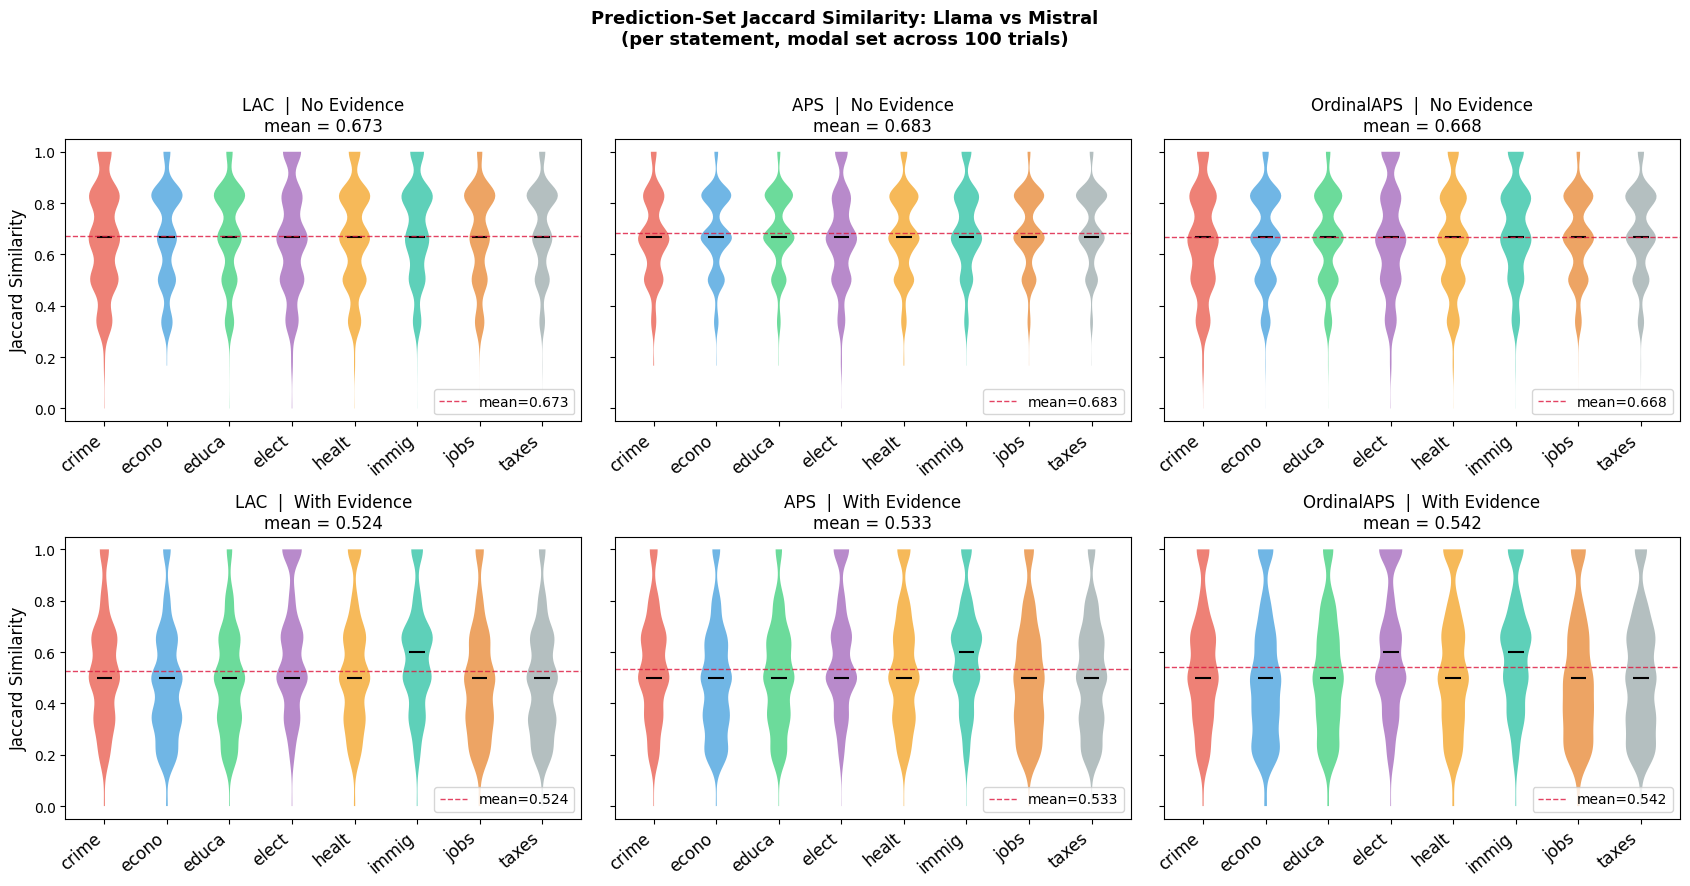

In [22]:
METHODS    = ['LAC', 'APS', 'OrdinalAPS']
CONDITIONS = ['No Evidence', 'With Evidence']

fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharey=True)
fig.suptitle('Prediction-Set Jaccard Similarity: Llama vs Mistral\n'
             '(per statement, modal set across 100 trials)', fontsize=13, fontweight='bold')

for r, cond in enumerate(CONDITIONS):
    for c, method in enumerate(METHODS):
        ax  = axes[r, c]
        sub = df_all[(df_all['method'] == method) & (df_all['condition'] == cond)]
        data_by_cat = [sub[sub['category'] == cat]['jaccard'].values for cat in CATEGORIES]

        vp = ax.violinplot(data_by_cat, positions=range(len(CATEGORIES)),
                           showmedians=True, showextrema=False)
        for pc, cat in zip(vp['bodies'], CATEGORIES):
            pc.set_facecolor(CATEGORY_COLORS[cat])
            pc.set_alpha(0.7)
        vp['cmedians'].set_color('black')
        vp['cmedians'].set_linewidth(1.5)

        mean_j = sub['jaccard'].mean()
        ax.axhline(mean_j, color='crimson', linestyle='--', linewidth=1, alpha=0.8,
                   label=f'mean={mean_j:.3f}')
        ax.set_xticks(range(len(CATEGORIES)))
        ax.set_xticklabels([cat[:5] for cat in CATEGORIES], rotation=40, ha='right', fontsize=12)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'{method}  |  {cond}\nmean = {mean_j:.3f}', fontsize=12)
        if c == 0:
            ax.set_ylabel('Jaccard Similarity', fontsize=12)
        ax.legend(fontsize=10, loc='lower right')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('visualisations_Jaccard/jaccard_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 2  Prediction Set Size Correlation

For each statement, compare Llama's and Mistral's average set size (across trials).
Spearman ρ quantifies monotonic agreement; the diagonal shows perfect agreement.


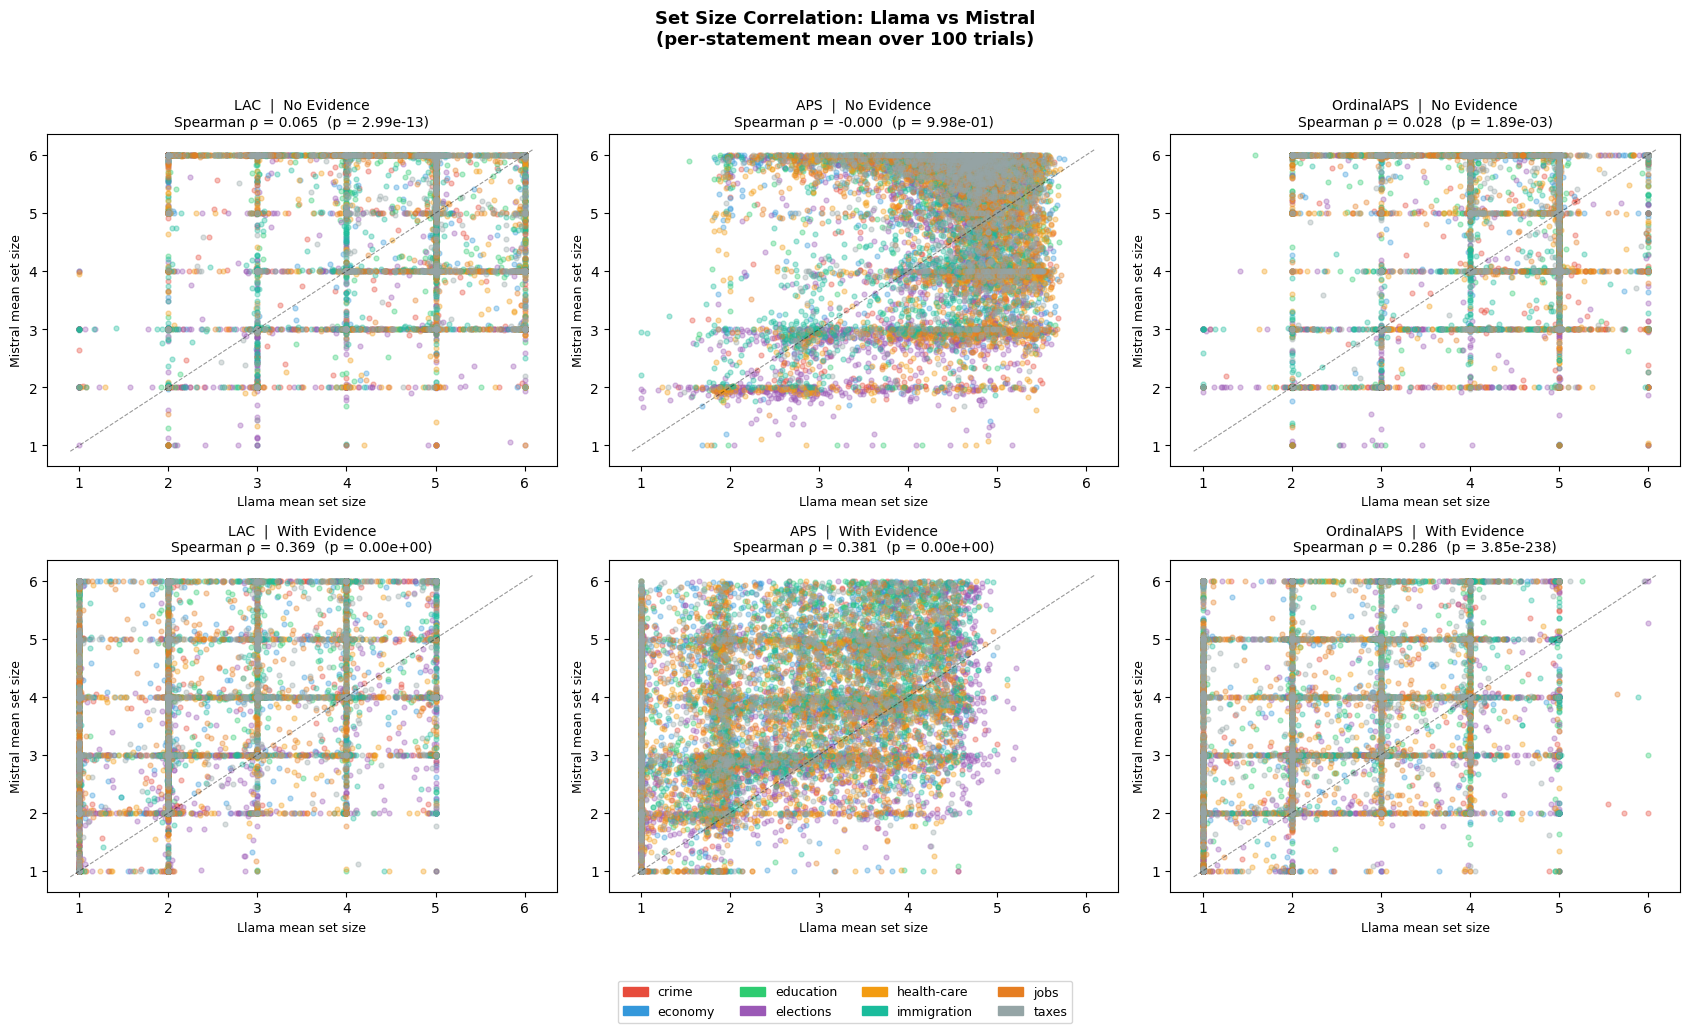

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Set Size Correlation: Llama vs Mistral\n(per-statement mean over 100 trials)',
             fontsize=13, fontweight='bold')

for r, cond in enumerate(CONDITIONS):
    for c, method in enumerate(METHODS):
        ax  = axes[r, c]
        sub = df_all[(df_all['method'] == method) & (df_all['condition'] == cond)]

        for cat in CATEGORIES:
            d = sub[sub['category'] == cat]
            ax.scatter(d['llama_mean_set_size'], d['mistral_mean_set_size'],
                       color=CATEGORY_COLORS[cat], alpha=0.35, s=12, label=cat)

        lo = min(sub['llama_mean_set_size'].min(), sub['mistral_mean_set_size'].min()) - 0.1
        hi = max(sub['llama_mean_set_size'].max(), sub['mistral_mean_set_size'].max()) + 0.1
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8, alpha=0.4, label='y = x')

        rho, pval = stats.spearmanr(sub['llama_mean_set_size'], sub['mistral_mean_set_size'])
        ax.set_title(f'{method}  |  {cond}\nSpearman ρ = {rho:.3f}  (p = {pval:.2e})', fontsize=10)
        ax.set_xlabel('Llama mean set size', fontsize=9)
        ax.set_ylabel('Mistral mean set size', fontsize=9)

handles = [mpatches.Patch(color=CATEGORY_COLORS[c], label=c) for c in CATEGORIES]
fig.legend(handles=handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.04), fontsize=9)
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.savefig('visualisations_Jaccard/set_size_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


## 3  Coverage Rate Correlation

Statement-level coverage rate (fraction of trials where the true label is in the
prediction set).  High correlation means both models agree on which statements are
hardest to cover.


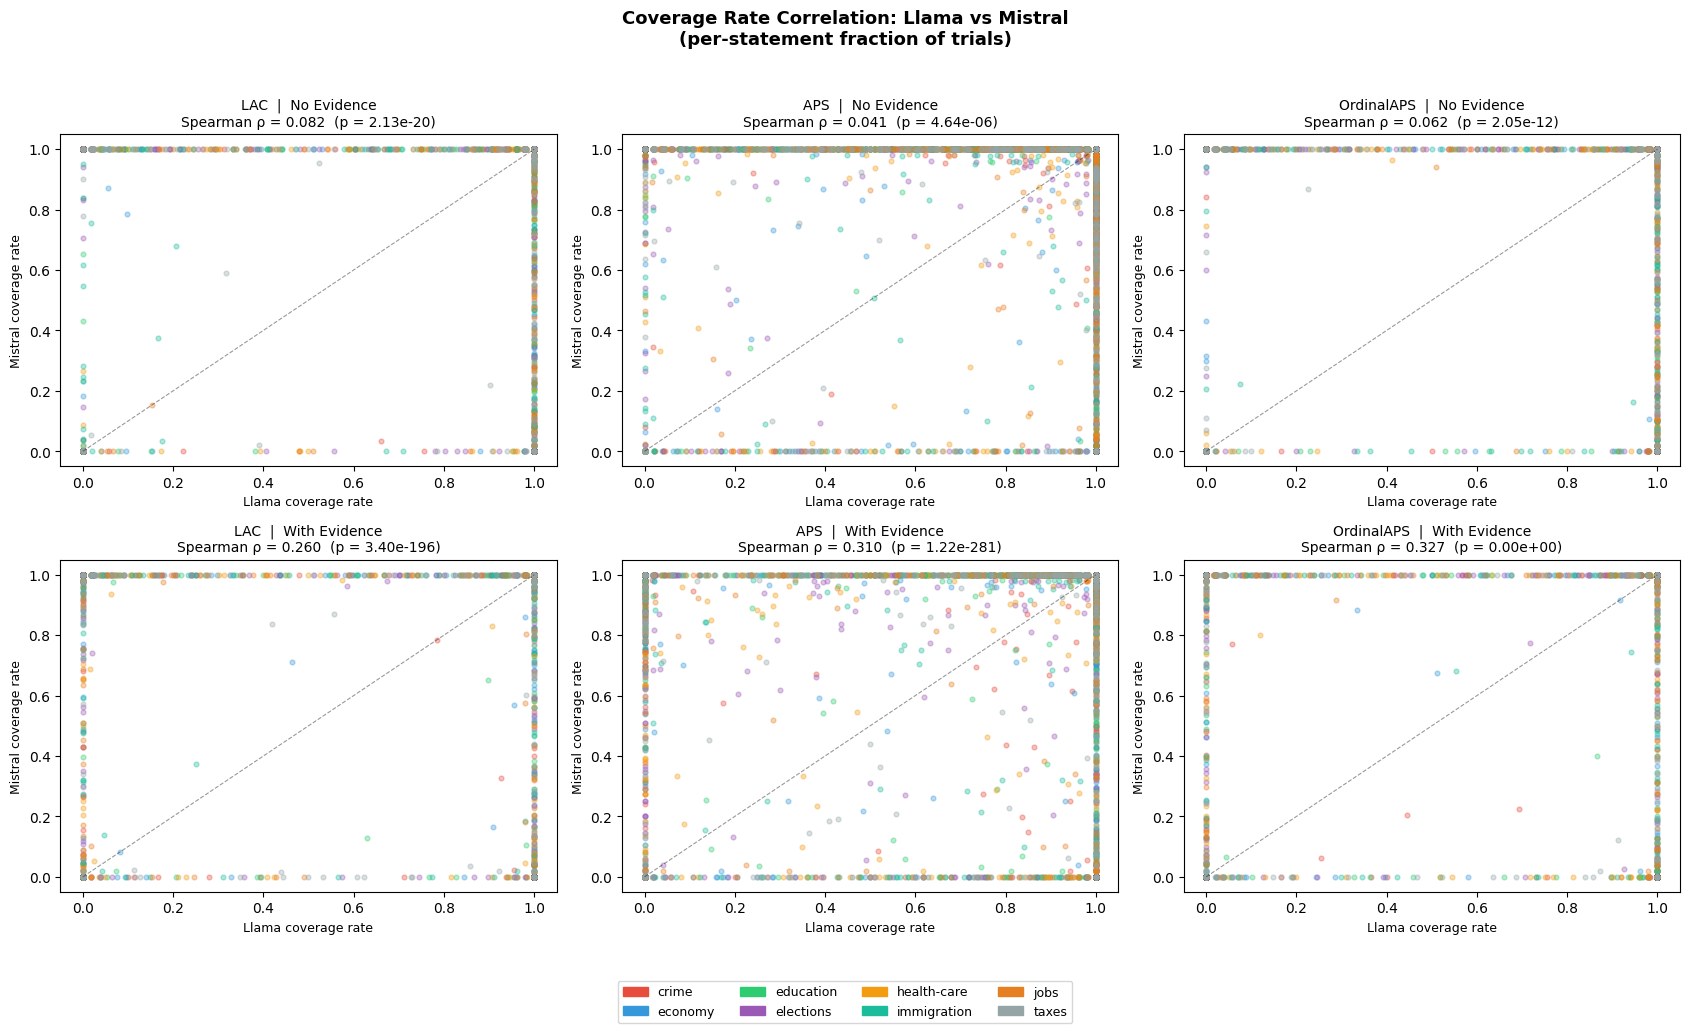

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Coverage Rate Correlation: Llama vs Mistral\n(per-statement fraction of trials)',
             fontsize=13, fontweight='bold')

for r, cond in enumerate(CONDITIONS):
    for c, method in enumerate(METHODS):
        ax  = axes[r, c]
        sub = df_all[(df_all['method'] == method) & (df_all['condition'] == cond)]

        for cat in CATEGORIES:
            d = sub[sub['category'] == cat]
            ax.scatter(d['llama_coverage_rate'], d['mistral_coverage_rate'],
                       color=CATEGORY_COLORS[cat], alpha=0.35, s=12)

        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.4)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)

        rho, pval = stats.spearmanr(sub['llama_coverage_rate'], sub['mistral_coverage_rate'])
        ax.set_title(f'{method}  |  {cond}\nSpearman ρ = {rho:.3f}  (p = {pval:.2e})', fontsize=10)
        ax.set_xlabel('Llama coverage rate', fontsize=9)
        ax.set_ylabel('Mistral coverage rate', fontsize=9)

handles = [mpatches.Patch(color=CATEGORY_COLORS[c], label=c) for c in CATEGORIES]
fig.legend(handles=handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.04), fontsize=9)
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.savefig('visualisations_Jaccard/coverage_rate_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


## 4  Per-Category Jaccard Heatmap

Average Jaccard similarity per (category × method), separately for no-evidence
and with-evidence.  Darker green = higher agreement between models.


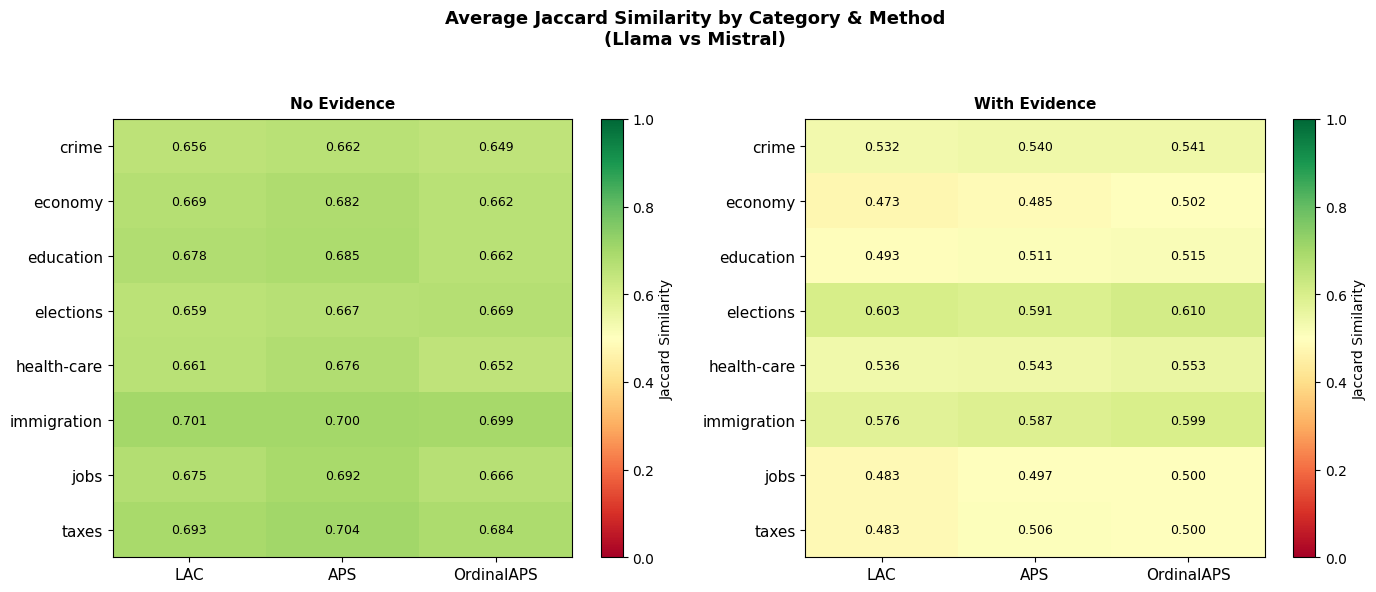

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Average Jaccard Similarity by Category & Method\n(Llama vs Mistral)',
             fontsize=13, fontweight='bold')

for ax_idx, cond in enumerate(CONDITIONS):
    ax   = axes[ax_idx]
    mat  = np.zeros((len(CATEGORIES), len(METHODS)))
    for ci, cat in enumerate(CATEGORIES):
        for mi, method in enumerate(METHODS):
            sub = df_all[(df_all['method'] == method) &
                         (df_all['condition'] == cond) &
                         (df_all['category'] == cat)]
            mat[ci, mi] = sub['jaccard'].mean()

    im = ax.imshow(mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels(METHODS, fontsize=11)
    ax.set_yticks(range(len(CATEGORIES)))
    ax.set_yticklabels(CATEGORIES, fontsize=11)
    ax.set_title(cond, fontsize=11, fontweight='bold', pad=8)

    for ci in range(len(CATEGORIES)):
        for mi in range(len(METHODS)):
            v = mat[ci, mi]
            fc = 'white' if (v < 0.30 or v > 0.75) else 'black'
            ax.text(mi, ci, f'{v:.3f}', ha='center', va='center', fontsize=9, color=fc)

    plt.colorbar(im, ax=ax, label='Jaccard Similarity')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('visualisations_Jaccard/jaccard_heatmap_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


## 5  Jaccard by True Verdict

Does model agreement vary by how extreme the true verdict is?
Box plots show Jaccard distributions grouped by true verdict label,
aggregated over all categories and pooled across methods × conditions.


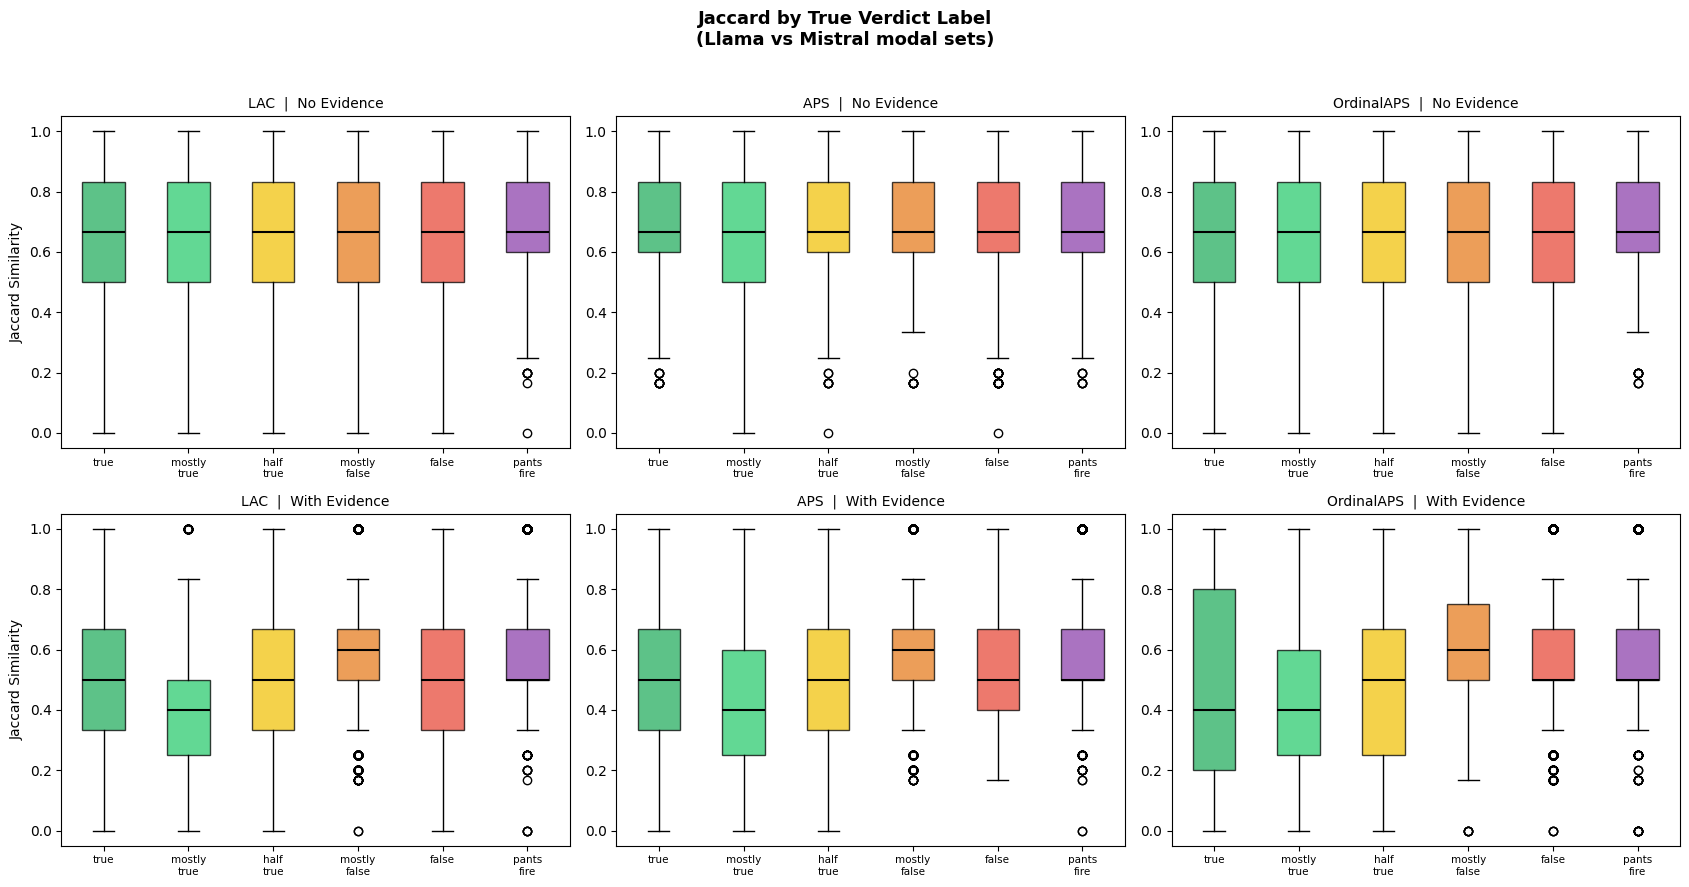

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('Jaccard by True Verdict Label\n(Llama vs Mistral modal sets)',
             fontsize=13, fontweight='bold')

VERDICT_COLORS = {
    'true':         '#27AE60',
    'mostly-true':  '#2ECC71',
    'half-true':    '#F1C40F',
    'mostly-false': '#E67E22',
    'false':        '#E74C3C',
    'pants-fire':   '#8E44AD',
}

for r, cond in enumerate(CONDITIONS):
    for c, method in enumerate(METHODS):
        ax  = axes[r, c]
        sub = df_all[(df_all['method'] == method) & (df_all['condition'] == cond)]
        data_by_v = [sub[sub['true_verdict'] == v]['jaccard'].values for v in VERDICTS]
        bp = ax.boxplot(data_by_v, patch_artist=True, medianprops={'color':'black','linewidth':1.5})
        for patch, v in zip(bp['boxes'], VERDICTS):
            patch.set_facecolor(VERDICT_COLORS[v])
            patch.set_alpha(0.75)
        ax.set_xticks(range(1, len(VERDICTS) + 1))
        ax.set_xticklabels([v.replace('-', '\n') for v in VERDICTS], fontsize=7.5)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'{method}  |  {cond}', fontsize=10)
        if c == 0:
            ax.set_ylabel('Jaccard Similarity', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('visualisations_Jaccard/jaccard_by_verdict.png', dpi=150, bbox_inches='tight')
plt.show()


## 6  Summary Statistics

Comprehensive table: mean/std Jaccard, % of statements with identical sets (Jaccard = 1),
Spearman ρ for set size and coverage rate, and mean absolute set-size difference.


In [23]:
rows = []
model_rows = []
for df, method, cond in all_conditions:
    rho_sz, p_sz   = stats.spearmanr(df['llama_mean_set_size'],  df['mistral_mean_set_size'])
    rho_cv, p_cv   = stats.spearmanr(df['llama_coverage_rate'],  df['mistral_coverage_rate'])
    rows.append({
        'Method':              method,
        'Condition':           cond,
        'N':                   len(df),
        'Mean Jaccard':        df['jaccard'].mean(),
        'Std Jaccard':         df['jaccard'].std(),
        'Jaccard=1 (%)':       (df['jaccard'] == 1.0).mean() * 100,
        'ρ set_size':          rho_sz,
        'p set_size':          p_sz,
        'ρ coverage_rate':     rho_cv,
        'p coverage_rate':     p_cv,
        'Mean |Δ set_size|':   (df['llama_mean_set_size'] - df['mistral_mean_set_size']).abs().mean(),
    })
    for model, prefix in [('Llama', 'llama'), ('Mistral', 'mistral')]:
        coverage_col = f'{prefix}_coverage_rate'
        size_col = f'{prefix}_mean_set_size'
        model_rows.append({
            'Method':        method,
            'Condition':     cond,
            'Model':         model,
            'N':             len(df),
            'Mean coverage': df[coverage_col].mean(),
            'Std coverage':  df[coverage_col].std(),
            'Mean set size': df[size_col].mean(),
            'Std set size':  df[size_col].std(),
        })

summary = pd.DataFrame(rows).set_index(['Method', 'Condition'])
model_summary = pd.DataFrame(model_rows).set_index(['Method', 'Condition', 'Model'])
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
print(summary.to_string())
print()
print(model_summary.to_string())

score_cols = [col for col in df_all.columns if 'nonconform' in col.lower() or col.lower().endswith('_score') or col.lower() == 'score']
if score_cols:
    print()
    print('Non-conformity score columns found in df_all:')
    print(score_cols)
    print(df_all[score_cols].agg(['mean', 'std']).T.to_string())
else:
    print()
    print('Non-conformity score columns are not present in these result CSVs, so no score summary can be computed from df_all.')


                              N  Mean Jaccard  Std Jaccard  Jaccard=1 (%)  ρ set_size  p set_size  ρ coverage_rate  p coverage_rate  Mean |Δ set_size|
Method     Condition                                                                                                                                  
LAC        No Evidence    12757        0.6730       0.1964         9.6810      0.0645      0.0000           0.0818           0.0000             1.3309
           With Evidence  12752        0.5243       0.2289         9.1986      0.3694      0.0000           0.2601           0.0000             1.5559
APS        No Evidence    12757        0.6830       0.1653         6.3651     -0.0000      0.9984           0.0405           0.0000             1.1571
           With Evidence  12752        0.5334       0.2233         8.5555      0.3812      0.0000           0.3098           0.0000             1.4332
OrdinalAPS No Evidence    12757        0.6675       0.1875         8.9049      0.0275      0.0

## 7  Per-Label Inclusion Probability Correlation

For each verdict label, plot Llama's vs Mistral's inclusion probability
(fraction of trials where that label appears in the prediction set), pooled
across all statements.  High correlation means both models assign similar
conformal uncertainty to each class.


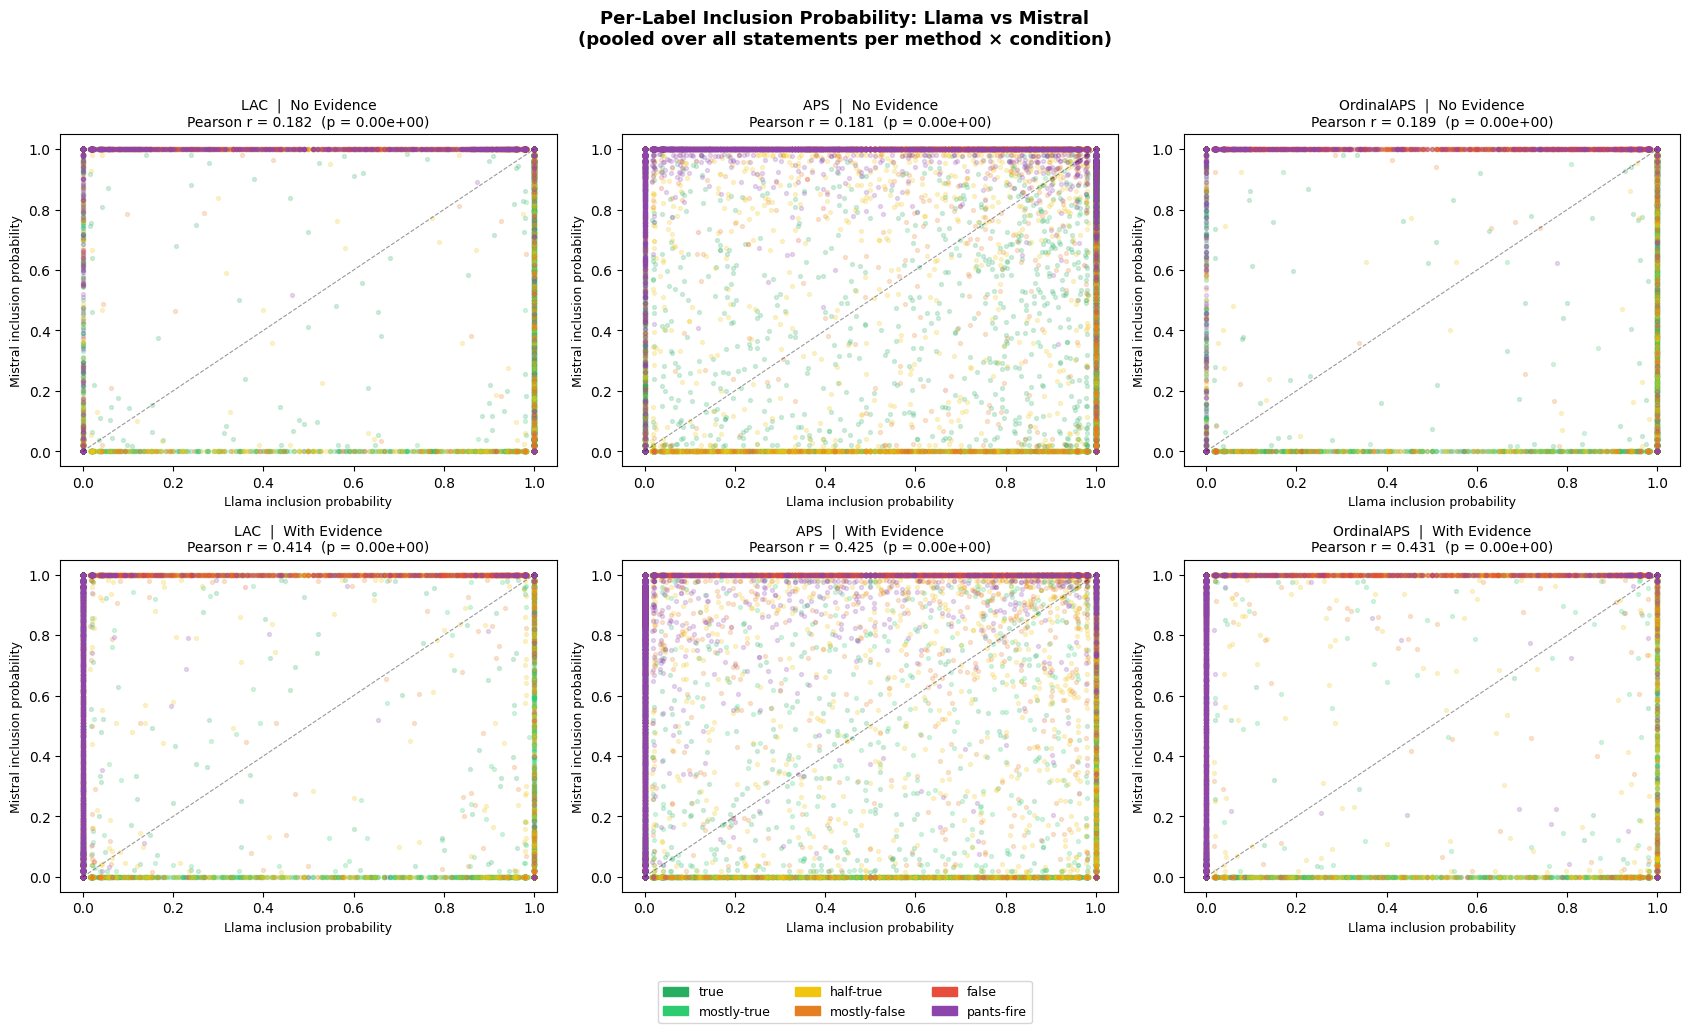

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Per-Label Inclusion Probability: Llama vs Mistral\n'
             '(pooled over all statements per method × condition)',
             fontsize=13, fontweight='bold')

for r, cond in enumerate(CONDITIONS):
    for c, method in enumerate(METHODS):
        ax  = axes[r, c]
        sub = df_all[(df_all['method'] == method) & (df_all['condition'] == cond)]

        for v in VERDICTS:
            l_col = f'llama_inc_{v}'
            m_col = f'mistral_inc_{v}'
            ax.scatter(sub[l_col], sub[m_col],
                       color=VERDICT_COLORS[v], alpha=0.2, s=8, label=v)

        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.4)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)

        # Pearson r across all (statement, label) pairs
        ll = pd.concat([sub[f'llama_inc_{v}']   for v in VERDICTS])
        mm = pd.concat([sub[f'mistral_inc_{v}'] for v in VERDICTS])
        r_val, pval = stats.pearsonr(ll, mm)
        ax.set_title(f'{method}  |  {cond}\nPearson r = {r_val:.3f}  (p = {pval:.2e})', fontsize=10)
        ax.set_xlabel('Llama inclusion probability', fontsize=9)
        ax.set_ylabel('Mistral inclusion probability', fontsize=9)

handles = [mpatches.Patch(color=VERDICT_COLORS[v], label=v) for v in VERDICTS]
fig.legend(handles=handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.04), fontsize=9)
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.savefig('visualisations_Jaccard/inclusion_prob_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
import ast
import pandas as pd


def normalize_label(value):
    return str(value).strip().lower()


def parse_prediction_set(value):
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except Exception:
            return []
    return []


def get_covered_mask(df):
    if 'is_covered' in df.columns:
        return df['is_covered'].astype(str).str.strip().str.lower().eq('true')
    if 'prediction_set' not in df.columns or 'true_verdict' not in df.columns:
        raise ValueError('Need either is_covered or prediction_set + true_verdict columns')
    return df.apply(
        lambda row: normalize_label(row['true_verdict']) in {normalize_label(x) for x in parse_prediction_set(row['prediction_set'])},
        axis=1,
    )


def collect_rows(csv_groups):
    frames = []
    for method, model, condition, csv_paths in csv_groups:
        for category, csv_path in csv_paths.items():
            df = pd.read_csv(csv_path)
            if 'true_verdict' not in df.columns or 'predicted_verdict' not in df.columns:
                raise ValueError(f'Missing verdict columns in {csv_path}')
            frame = pd.DataFrame({
                'method': method,
                'model': model,
                'condition': condition,
                'category': category,
                'match': df['true_verdict'].map(normalize_label) == df['predicted_verdict'].map(normalize_label),
                'covered': get_covered_mask(df),
            })
            frames.append(frame)
    return pd.concat(frames, ignore_index=True)


csv_groups = [
    ('LAC', 'Llama', 'No Evidence', no_evidence_lac_llama_csv),
    ('LAC', 'Llama', 'With Evidence', with_evidence_lac_llama_csv),
    ('LAC', 'Mistral', 'No Evidence', no_evidence_lac_mistral_csv),
    ('LAC', 'Mistral', 'With Evidence', with_evidence_lac_mistral_csv),
    ('APS', 'Llama', 'No Evidence', no_evidence_aps_llama_csv),
    ('APS', 'Llama', 'With Evidence', with_evidence_aps_llama_csv),
    ('APS', 'Mistral', 'No Evidence', no_evidence_aps_mistral_csv),
    ('APS', 'Mistral', 'With Evidence', with_evidence_aps_mistral_csv),
    ('Ordinal-APS', 'Llama', 'No Evidence', no_evidence_ordinalaps_llama_csv),
    ('Ordinal-APS', 'Llama', 'With Evidence', with_evidence_ordinalaps_llama_csv),
    ('Ordinal-APS', 'Mistral', 'No Evidence', no_evidence_ordinalaps_mistral_csv),
    ('Ordinal-APS', 'Mistral', 'With Evidence', with_evidence_ordinalaps_mistral_csv),
]

all_rows = collect_rows(csv_groups)
summary = all_rows.groupby(['method', 'model', 'condition', 'match']).agg(
    total_rows=('covered', 'size'),
    covered_rows=('covered', 'sum'),
).reset_index()
summary['coverage_rate'] = summary['covered_rows'] / summary['total_rows']
summary['verdict_relation'] = summary['match'].map({
    True: 'correct prediction',
    False: 'incorrect prediction',
})
summary = summary[['method', 'model', 'condition', 'verdict_relation', 'total_rows', 'covered_rows', 'coverage_rate']]
summary['coverage_rate'] = summary['coverage_rate'].map(lambda v: f'{v:.2%}')
summary['covered_rows'] = summary['covered_rows'].map(lambda v: f'{v:,}')
summary['total_rows'] = summary['total_rows'].map(lambda v: f'{v:,}')
summary['verdict_relation'] = pd.Categorical(
    summary['verdict_relation'],
    categories=['correct prediction', 'incorrect prediction'],
    ordered=True,
)
summary = summary.sort_values(['method', 'model', 'condition', 'verdict_relation'], kind='stable').reset_index(drop=True)
summary['verdict_relation'] = summary['verdict_relation'].astype(str)

print('Prediction-set coverage by non-conformity score, model, and evidence setting')
print('Split by whether the verdict matches.')
print(summary.to_string(index=False))

Prediction-set coverage by non-conformity score, model, and evidence setting
Split by whether the verdict matches.
     method   model     condition     verdict_relation total_rows covered_rows coverage_rate
        APS   Llama   No Evidence   correct prediction    186,484      186,484       100.00%
        APS   Llama   No Evidence incorrect prediction    451,616      388,198        85.96%
        APS   Llama With Evidence   correct prediction    389,851      389,851       100.00%
        APS   Llama With Evidence incorrect prediction    248,249      192,805        77.67%
        APS Mistral   No Evidence   correct prediction    173,794      173,794       100.00%
        APS Mistral   No Evidence incorrect prediction    464,306      401,238        86.42%
        APS Mistral With Evidence   correct prediction    259,845      259,845       100.00%
        APS Mistral With Evidence incorrect prediction    378,255      314,657        83.19%
        LAC   Llama   No Evidence   correct pred

In [13]:
import pandas as pd


def parse_prediction_set(value):
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except Exception:
            return []
    return []


def extract_set_size(df):
    if 'set_size' in df.columns:
        return pd.to_numeric(df['set_size'], errors='coerce')
    if 'prediction_set' in df.columns:
        return df['prediction_set'].apply(lambda value: len(parse_prediction_set(value)))
    raise ValueError('Need either set_size or prediction_set in the CSV')


def summarize_csvs(csv_groups):
    rows = []
    for method, model, condition, csv_paths in csv_groups:
        for category, csv_path in csv_paths.items():
            df = pd.read_csv(csv_path)
            sizes = extract_set_size(df)
            rows.append({
                'method': method,
                'model': model,
                'condition': condition,
                'category': category,
                'count': int(sizes.notna().sum()),
                'mean_set_size': sizes.mean(),
                'std_set_size': sizes.std(),
            })
    return pd.DataFrame(rows)


summary = summarize_csvs(csv_groups)
summary = summary[[
    'model',
    'method',
    'condition',
    'category',
    'count',
    'mean_set_size',
    'std_set_size',
]].sort_values(['model', 'method', 'condition', 'category'], kind='stable').reset_index(drop=True)
summary['mean_set_size'] = summary['mean_set_size'].map(lambda value: f'{value:.4f}')
summary['std_set_size'] = summary['std_set_size'].map(lambda value: f'{value:.4f}')
summary['count'] = summary['count'].map(lambda value: f'{value:,}')

print('Mean and standard deviation of prediction set size by model, method, category, and evidence setting')
print(summary.to_string(index=False))

Mean and standard deviation of prediction set size by model, method, category, and evidence setting
  model      method     condition    category   count mean_set_size std_set_size
  Llama         APS   No Evidence       crime  55,000        4.3637       0.9520
  Llama         APS   No Evidence     economy  97,800        4.4709       0.8929
  Llama         APS   No Evidence   education  67,600        4.4780       0.8541
  Llama         APS   No Evidence   elections 100,200        4.1039       1.0579
  Llama         APS   No Evidence health-care 105,400        4.4616       0.9622
  Llama         APS   No Evidence immigration  68,300        4.1831       0.9640
  Llama         APS   No Evidence        jobs  59,000        4.5582       0.8129
  Llama         APS   No Evidence       taxes  84,800        4.5779       0.7790
  Llama         APS With Evidence       crime  55,000        2.5155       1.2861
  Llama         APS With Evidence     economy  97,800        2.3331       1.2027
  Llama  

In [14]:
import ast
import pandas as pd


def normalize_label(value):
    return str(value).strip().lower()


def parse_prediction_set(value):
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except Exception:
            return []
    return []


def extract_set_size(df):
    if 'set_size' in df.columns:
        return pd.to_numeric(df['set_size'], errors='coerce')
    if 'prediction_set' in df.columns:
        return df['prediction_set'].apply(lambda value: len(parse_prediction_set(value)))
    raise ValueError('Need either set_size or prediction_set in the CSV')


def extract_accuracy(df):
    if 'true_verdict' not in df.columns or 'predicted_verdict' not in df.columns:
        raise ValueError('Missing verdict columns')
    return df['true_verdict'].map(normalize_label) == df['predicted_verdict'].map(normalize_label)


def summarize_accuracy_by_size(csv_groups):
    rows = []
    for method, model, condition, csv_paths in csv_groups:
        for category, csv_path in csv_paths.items():
            df = pd.read_csv(csv_path)
            set_sizes = extract_set_size(df)
            accuracy = extract_accuracy(df)

            for size in range(1, 7):
                mask = set_sizes == size
                rows.append({
                    'method': method,
                    'model': model,
                    'condition': condition,
                    'category': category,
                    'set_size': size,
                    'count': int(mask.sum()),
                    'correct': int((accuracy & mask).sum()),
                })

    summary = pd.DataFrame(rows)
    summary = summary.groupby(['method', 'model', 'condition', 'set_size']).agg(
        count=('count', 'sum'),
        correct=('correct', 'sum'),
    ).reset_index()
    summary['accuracy'] = summary['correct'] / summary['count']
    return summary


summary = summarize_accuracy_by_size(csv_groups)
summary['set_size'] = summary['set_size'].astype(int)
summary = summary.sort_values(['model', 'method', 'condition', 'set_size'], kind='stable').reset_index(drop=True)

latex_input = summary.copy()
latex_input['method'] = latex_input['method'] + ' -- ' + latex_input['condition']
latex_input = latex_input[['model', 'method', 'set_size', 'accuracy']]

latex_table = (
    latex_input
    .pivot_table(index=['model', 'method'], columns='set_size', values='accuracy', aggfunc='first')
    .rename(columns={size: f'Size {size}' for size in range(1, 7)})
    .reset_index()
)

latex_table['model'] = pd.Categorical(latex_table['model'], categories=['Llama', 'Mistral'], ordered=True)
latex_table = latex_table.sort_values(['model', 'method'], kind='stable').reset_index(drop=True)
latex_table.columns = ['Model', 'Method'] + [f'Size {size}' for size in range(1, 7)]

latex_table = latex_table.fillna('')
for size in range(1, 7):
    latex_table[f'Size {size}'] = latex_table[f'Size {size}'].map(lambda value: f'{value:.2%}' if isinstance(value, (int, float)) or pd.notna(value) and value != '' else value)

latex_output = latex_table.to_latex(
    index=False,
    escape=False,
    column_format='llrrrrrr',
    caption='Prediction accuracy by prediction-set size, grouped by model and evidence condition.',
    label='tab:prediction_accuracy_by_size',
)

print(latex_output)


Prediction accuracy for prediction set size = 1
     method   model     condition   count correct accuracy
        APS   Llama   No Evidence   2,297   1,062   46.23%
        APS   Llama With Evidence 193,728 182,278   94.09%
        APS Mistral   No Evidence   2,989   1,099   36.77%
        APS Mistral With Evidence  29,927  24,451   81.70%
        LAC   Llama   No Evidence   2,557   1,810   70.79%
        LAC   Llama With Evidence 196,186 185,785   94.70%
        LAC Mistral   No Evidence   2,550     893   35.02%
        LAC Mistral With Evidence  28,844  23,531   81.58%
Ordinal-APS   Llama   No Evidence   2,410   1,518   62.99%
Ordinal-APS   Llama With Evidence 207,176 195,581   94.40%
Ordinal-APS Mistral   No Evidence   2,228     703   31.55%
Ordinal-APS Mistral With Evidence  39,439  31,671   80.30%

Prediction accuracy for prediction set size = 2
     method   model     condition   count correct accuracy
        APS   Llama   No Evidence  30,233  13,246   43.81%
        APS   Llam

In [ ]:
from __future__ import annotations

import argparse
import csv
import json
from collections import defaultdict
from datetime import datetime, date
from pathlib import Path
from typing import Dict, Iterable, Optional


CUTOFFS = {
    "llama": date(2023, 12, 1),
    "mistral": date(2023, 9, 1),
}


def get_repo_root() -> Path:
    # src/analysis/<this_file>.py -> repo root is two levels up.
    return Path(__file__).resolve().parents[2]


def normalize_statement(text: str) -> str:
    if text is None:
        return ""
    s = str(text)
    replacements = {
        "\u2018": "'",
        "\u2019": "'",
        "\u201c": '"',
        "\u201d": '"',
        "\u00a0": " ",
    }
    for old, new in replacements.items():
        s = s.replace(old, new)

    s = s.strip().strip('"').strip("'")
    s = " ".join(s.split())
    return s.lower()


def parse_statement_date(raw: str) -> Optional[date]:
    if not raw:
        return None

    value = str(raw).strip()
    formats = [
        "%B %d, %Y",   # January 11, 2026
        "%b %d, %Y",   # Jan 11, 2026
        "%Y-%m-%d",    # 2026-01-11
        "%m/%d/%Y",    # 01/11/2026
        "%Y/%m/%d",    # 2026/01/11
    ]
    for fmt in formats:
        try:
            return datetime.strptime(value, fmt).date()
        except ValueError:
            pass

    try:
        return datetime.fromisoformat(value).date()
    except ValueError:
        return None


def infer_model_from_path(csv_path: Path) -> Optional[str]:
    parts = [p.lower() for p in csv_path.parts]
    if "llama" in parts:
        return "llama"
    if "mistral" in parts:
        return "mistral"
    return None


def parse_bool(value: object) -> Optional[bool]:
    if value is None:
        return None
    text = str(value).strip().lower()
    if text in {"true", "1", "yes", "y", "t"}:
        return True
    if text in {"false", "0", "no", "n", "f"}:
        return False
    return None


def build_statement_date_index(datasets_dir: Path) -> Dict[str, date]:
    index: Dict[str, date] = {}
    collisions = 0

    for json_path in sorted(datasets_dir.rglob("*.json")):
        with json_path.open("r", encoding="utf-8") as f:
            try:
                data = json.load(f)
            except json.JSONDecodeError:
                continue

        if not isinstance(data, list):
            continue

        for item in data:
            if not isinstance(item, dict):
                continue

            statement = item.get("statement")
            statement_date_raw = item.get("statement_date")
            if not statement or not statement_date_raw:
                continue

            key = normalize_statement(statement)
            dt = parse_statement_date(statement_date_raw)
            if not key or dt is None:
                continue

            if key in index and index[key] != dt:
                collisions += 1
                if dt < index[key]:
                    index[key] = dt
            else:
                index[key] = dt

    if collisions:
        print(f"[info] Resolved {collisions} statement_date collisions by keeping earliest date.")

    return index


def iter_csv_files(scan_dirs: Iterable[Path], max_csvs: Optional[int] = None) -> Iterable[Path]:
    count = 0
    for base in scan_dirs:
        if not base.exists():
            continue
        for csv_path in base.rglob("*.csv"):
            if "venv" in {p.lower() for p in csv_path.parts}:
                continue
            yield csv_path
            count += 1
            if max_csvs is not None and count >= max_csvs:
                return


def analyze_csv_file(csv_path: Path, statement_date_index: Dict[str, date], repo_root: Path) -> Optional[dict]:
    model = infer_model_from_path(csv_path)
    if model not in CUTOFFS:
        return None

    cutoff = CUTOFFS[model]

    try:
        with csv_path.open("r", encoding="utf-8", newline="") as f:
            reader = csv.DictReader(f)
            if reader.fieldnames is None:
                return None

            fieldnames_lower = {name.lower() for name in reader.fieldnames if name}
            if "statement" not in fieldnames_lower or "is_covered" not in fieldnames_lower:
                return None

            before_total = 0
            before_covered = 0
            after_total = 0
            after_covered = 0
            missing_statement_date = 0
            invalid_is_covered = 0
            total_rows = 0
            matched_rows = 0

            for row in reader:
                total_rows += 1
                statement = row.get("statement")
                is_covered = parse_bool(row.get("is_covered"))

                if is_covered is None:
                    invalid_is_covered += 1
                    continue

                key = normalize_statement(statement)
                statement_date = statement_date_index.get(key)

                if statement_date is None:
                    missing_statement_date += 1
                    continue

                matched_rows += 1

                if statement_date < cutoff:
                    before_total += 1
                    if is_covered:
                        before_covered += 1
                else:
                    after_total += 1
                    if is_covered:
                        after_covered += 1

    except UnicodeDecodeError:
        try:
            with csv_path.open("r", encoding="latin-1", newline="") as f:
                reader = csv.DictReader(f)
                if reader.fieldnames is None:
                    return None

                fieldnames_lower = {name.lower() for name in reader.fieldnames if name}
                if "statement" not in fieldnames_lower or "is_covered" not in fieldnames_lower:
                    return None

                before_total = 0
                before_covered = 0
                after_total = 0
                after_covered = 0
                missing_statement_date = 0
                invalid_is_covered = 0
                total_rows = 0
                matched_rows = 0

                for row in reader:
                    total_rows += 1
                    statement = row.get("statement")
                    is_covered = parse_bool(row.get("is_covered"))

                    if is_covered is None:
                        invalid_is_covered += 1
                        continue

                    key = normalize_statement(statement)
                    statement_date = statement_date_index.get(key)

                    if statement_date is None:
                        missing_statement_date += 1
                        continue

                    matched_rows += 1

                    if statement_date < cutoff:
                        before_total += 1
                        if is_covered:
                            before_covered += 1
                    else:
                        after_total += 1
                        if is_covered:
                            after_covered += 1
        except Exception as exc:
            print(f"[warn] Failed to read {csv_path}: {exc}")
            return None
    except Exception as exc:
        print(f"[warn] Failed to read {csv_path}: {exc}")
        return None

    return {
        "csv_path": str(csv_path.relative_to(repo_root)).replace("\\", "/"),
        "model": model,
        "cutoff_date": cutoff.isoformat(),
        "total_rows": total_rows,
        "matched_rows": matched_rows,
        "missing_statement_date": missing_statement_date,
        "invalid_is_covered": invalid_is_covered,
        "before_total": before_total,
        "before_covered": before_covered,
        "before_coverage": (before_covered / before_total) if before_total else "",
        "after_total": after_total,
        "after_covered": after_covered,
        "after_coverage": (after_covered / after_total) if after_total else "",
    }


def write_summary(rows: list[dict], output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = [
        "csv_path",
        "model",
        "cutoff_date",
        "total_rows",
        "matched_rows",
        "missing_statement_date",
        "invalid_is_covered",
        "before_total",
        "before_covered",
        "before_coverage",
        "after_total",
        "after_covered",
        "after_coverage",
    ]

    with output_path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def print_human_summary(rows: list[dict]) -> None:
    print("\nPer-CSV coverage (before vs after cutoff):")
    print("=" * 80)
    for row in rows:
        before_cov = row["before_coverage"]
        after_cov = row["after_coverage"]

        before_cov_txt = "n/a" if before_cov == "" else f"{before_cov:.4f}"
        after_cov_txt = "n/a" if after_cov == "" else f"{after_cov:.4f}"

        print(f"{row['csv_path']}")
        print(
            f"  model={row['model']} cutoff={row['cutoff_date']} | "
            f"before={before_cov_txt} ({row['before_covered']}/{row['before_total']}) | "
            f"after={after_cov_txt} ({row['after_covered']}/{row['after_total']}) | "
            f"matched={row['matched_rows']}/{row['total_rows']}"
        )
    print("=" * 80)


def parse_args() -> argparse.Namespace:
    repo_root = get_repo_root()
    default_results = repo_root / "results"
    default_old_results = repo_root / "old_results"
    default_datasets = repo_root / "datasets"
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    default_output = repo_root / "results" / f"coverage_before_after_cutoff_{timestamp}.csv"

    parser = argparse.ArgumentParser(
        description=(
            "Compute per-CSV coverage before/after model cutoff by joining result CSV statements "
            "with statement_date from dataset JSON files."
        )
    )
    parser.add_argument(
        "--scan-dir",
        dest="scan_dirs",
        action="append",
        default=[str(default_results), str(default_old_results)],
        help="Directory to recursively scan for CSV files (can be passed multiple times).",
    )
    parser.add_argument(
        "--datasets-dir",
        default=str(default_datasets),
        help="Directory containing dataset JSON files with statement_date.",
    )
    parser.add_argument(
        "--output",
        default=str(default_output),
        help="Output CSV path for per-file before/after coverage summary.",
    )
    parser.add_argument(
        "--max-csvs",
        type=int,
        default=None,
        help="Optional limit on number of CSV files to scan (useful for quick tests).",
    )
    parser.add_argument(
        "--silent",
        action="store_true",
        help="If set, only write output CSV and do not print per-file summary.",
    )
    return parser.parse_args()


def main() -> None:
    args = parse_args()
    repo_root = get_repo_root()

    datasets_dir = Path(args.datasets_dir)
    scan_dirs = [Path(p) for p in args.scan_dirs]
    output_path = Path(args.output)

    print("Building statement->date index from datasets...")
    statement_date_index = build_statement_date_index(datasets_dir)
    print(f"Loaded {len(statement_date_index)} unique statements with parsable dates.")

    rows: list[dict] = []
    scanned = 0
    analyzed = 0

    for csv_path in iter_csv_files(scan_dirs, max_csvs=args.max_csvs):
        scanned += 1
        result = analyze_csv_file(csv_path, statement_date_index, repo_root)
        if result is not None:
            rows.append(result)
            analyzed += 1

    rows.sort(key=lambda r: r["csv_path"])
    write_summary(rows, output_path)

    print(f"Scanned CSV files: {scanned}")
    print(f"Analyzed CSV files: {analyzed}")
    print(f"Summary written to: {output_path}")

    if not args.silent:
        print_human_summary(rows)


if __name__ == "__main__":
    main()


In [ ]:
from pathlib import Path
import json
from datetime import datetime, date
import pandas as pd

CUTOFFS = {
    "llama": date(2023, 12, 1),
    "mistral": date(2023, 9, 1),
}


def normalize_statement(text):
    if text is None:
        return ""
    s = str(text)
    replacements = {
        "\u2018": "'",
        "\u2019": "'",
        "\u201c": '"',
        "\u201d": '"',
        "\u00a0": " ",
    }
    for old, new in replacements.items():
        s = s.replace(old, new)
    s = s.strip().strip('"').strip("'")
    s = " ".join(s.split())
    return s.lower()


def parse_statement_date(raw):
    if not raw:
        return None
    value = str(raw).strip()
    formats = ["%B %d, %Y", "%b %d, %Y", "%Y-%m-%d", "%m/%d/%Y", "%Y/%m/%d"]
    for fmt in formats:
        try:
            return datetime.strptime(value, fmt).date()
        except ValueError:
            pass
    try:
        return datetime.fromisoformat(value).date()
    except ValueError:
        return None


def parse_covered(value):
    txt = str(value).strip().lower()
    if txt in {"true", "1", "yes", "y", "t"}:
        return True
    if txt in {"false", "0", "no", "n", "f"}:
        return False
    return None


def find_repo_root(start: Path):
    cur = start.resolve()
    for candidate in [cur] + list(cur.parents):
        if (candidate / "datasets").exists() and (candidate / "results").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing datasets/ and results/")


def build_statement_date_index(datasets_dir: Path):
    idx = {}
    for json_path in sorted(datasets_dir.rglob("*.json")):
        try:
            data = json.loads(json_path.read_text(encoding="utf-8"))
        except Exception:
            continue
        if not isinstance(data, list):
            continue
        for row in data:
            if not isinstance(row, dict):
                continue
            stmt = row.get("statement")
            dt_raw = row.get("statement_date")
            if not stmt or not dt_raw:
                continue
            dt = parse_statement_date(dt_raw)
            if dt is None:
                continue
            key = normalize_statement(stmt)
            if key in idx:
                if dt < idx[key]:
                    idx[key] = dt
            else:
                idx[key] = dt
    return idx


# Use the CSV dictionaries already defined in this notebook.
csv_groups = [
    ("LAC", "llama", "No Evidence", no_evidence_lac_llama_csv),
    ("LAC", "llama", "With Evidence", with_evidence_lac_llama_csv),
    ("LAC", "mistral", "No Evidence", no_evidence_lac_mistral_csv),
    ("LAC", "mistral", "With Evidence", with_evidence_lac_mistral_csv),
    ("APS", "llama", "No Evidence", no_evidence_aps_llama_csv),
    ("APS", "llama", "With Evidence", with_evidence_aps_llama_csv),
    ("APS", "mistral", "No Evidence", no_evidence_aps_mistral_csv),
    ("APS", "mistral", "With Evidence", with_evidence_aps_mistral_csv),
    ("OrdinalAPS", "llama", "No Evidence", no_evidence_ordinalaps_llama_csv),
    ("OrdinalAPS", "llama", "With Evidence", with_evidence_ordinalaps_llama_csv),
    ("OrdinalAPS", "mistral", "No Evidence", no_evidence_ordinalaps_mistral_csv),
    ("OrdinalAPS", "mistral", "With Evidence", with_evidence_ordinalaps_mistral_csv),
]

repo_root = find_repo_root(Path.cwd())
statement_date_index = build_statement_date_index(repo_root / "datasets")

rows = []
for method, model, condition, csv_map in csv_groups:
    cutoff = CUTOFFS[model]
    for category, csv_path in csv_map.items():
        df = pd.read_csv(csv_path)
        if "statement" not in df.columns or "is_covered" not in df.columns:
            continue

        before_total = 0
        before_covered = 0
        after_total = 0
        after_covered = 0
        missing_date = 0

        for _, r in df.iterrows():
            is_cov = parse_covered(r.get("is_covered"))
            if is_cov is None:
                continue

            stmt_key = normalize_statement(r.get("statement"))
            st_date = statement_date_index.get(stmt_key)
            if st_date is None:
                missing_date += 1
                continue

            if st_date < cutoff:
                before_total += 1
                if is_cov:
                    before_covered += 1
            else:
                after_total += 1
                if is_cov:
                    after_covered += 1

        rows.append({
            "method": method,
            "model": model,
            "condition": condition,
            "category": category,
            "csv_path": csv_path,
            "cutoff": cutoff.isoformat(),
            "before_total": before_total,
            "before_covered": before_covered,
            "before_coverage": (before_covered / before_total) if before_total else float("nan"),
            "after_total": after_total,
            "after_covered": after_covered,
            "after_coverage": (after_covered / after_total) if after_total else float("nan"),
            "missing_statement_date": missing_date,
        })

stats_df = pd.DataFrame(rows).sort_values(
    ["method", "model", "condition", "category"], kind="stable"
).reset_index(drop=True)

print("Per-CSV coverage before/after model cutoff (no files written):")
print(stats_df[[
    "method", "model", "condition", "category",
    "before_covered", "before_total", "before_coverage",
    "after_covered", "after_total", "after_coverage",
    "missing_statement_date"
]].to_string(index=False))

summary_df = stats_df.groupby(["method", "model", "condition"], as_index=False).agg(
    before_covered=("before_covered", "sum"),
    before_total=("before_total", "sum"),
    after_covered=("after_covered", "sum"),
    after_total=("after_total", "sum"),
    missing_statement_date=("missing_statement_date", "sum"),
)
summary_df["before_coverage"] = summary_df["before_covered"] / summary_df["before_total"]
summary_df["after_coverage"] = summary_df["after_covered"] / summary_df["after_total"]

print("\nAggregated coverage by method/model/condition:")
print(summary_df[[
    "method", "model", "condition",
    "before_covered", "before_total", "before_coverage",
    "after_covered", "after_total", "after_coverage",
    "missing_statement_date"
]].to_string(index=False))